In [1]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

# Pre-processing

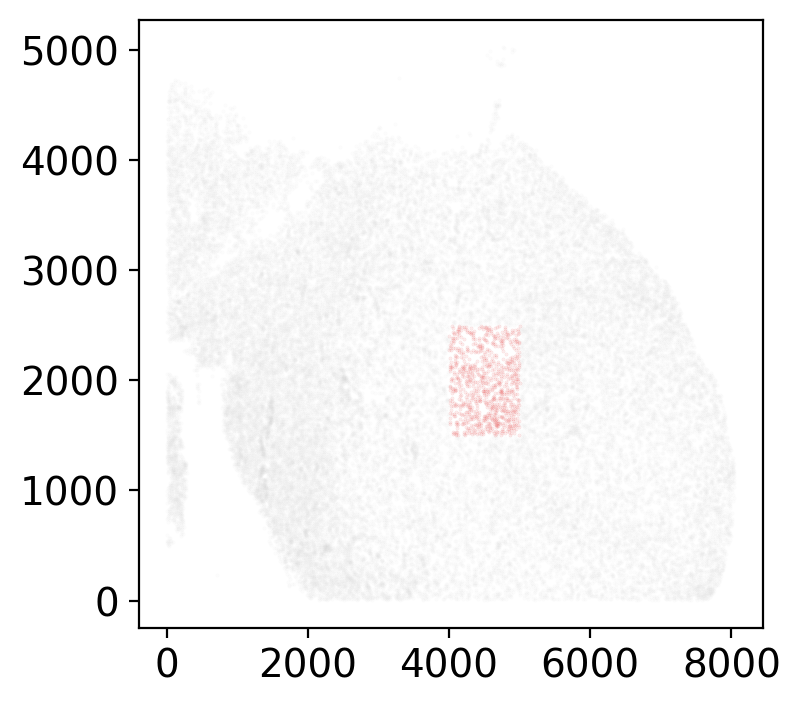

In [2]:
# > gbm
# read in xenium
avis = sc.read_10x_h5('data/Xenium_V1_FFPE_Human_Brain_Glioblastoma_With_Addon_outs/cell_feature_matrix.h5')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# remove cells with no counts
sc.pp.filter_cells(avis, min_counts=100)
# normalize the data
sc.pp.normalize_total(avis, target_sum=1e6)
sc.pp.log1p(avis)
# read in the spatial
df = pd.read_csv('data/Xenium_V1_FFPE_Human_Brain_Glioblastoma_With_Addon_outs/cells.csv.gz', index_col=0)
df = df.loc[avis.obs.index]
avis.obsm['spatial'] = df[['x_centroid','y_centroid']].values
avis.obs['sample_id'] = 'sample'
# view the tissue and choose a specific area to focus on
fig, ax = plt.subplots()
ax.grid(False)
ax.scatter(df['x_centroid'], df['y_centroid'], s=0.1, alpha=0.1, color='lightgray')
mask = (df['x_centroid'] < 5000) & (df['x_centroid'] > 4000)
mask = mask & (df['y_centroid'] < 2500) & (df['y_centroid'] > 1500)
ax.scatter(df.loc[mask, 'x_centroid'], df.loc[mask, 'y_centroid'], s=0.1, alpha=0.1, color='r')
avis1 = avis[mask].copy()

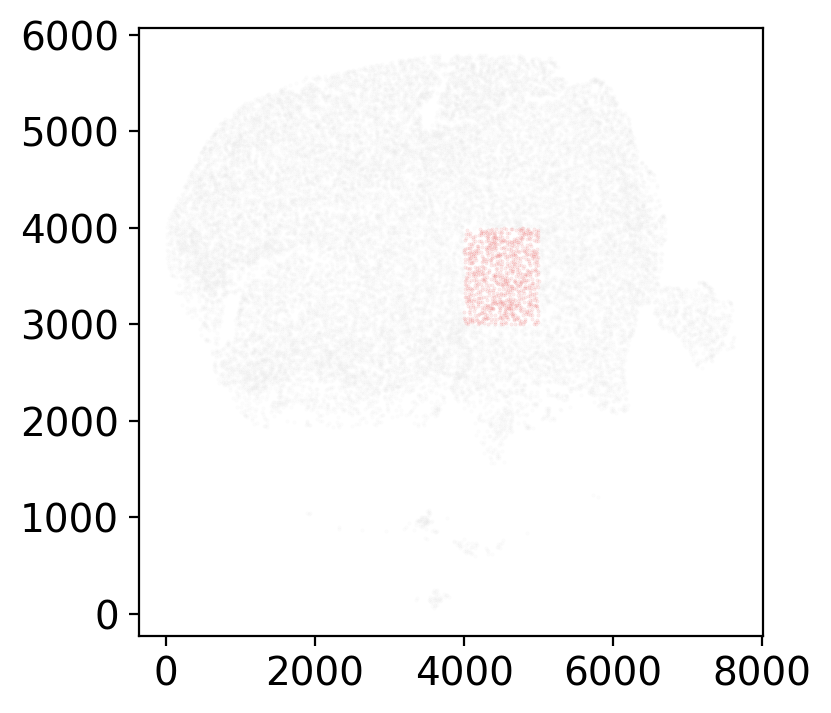

In [3]:
# > healthy
# read in xenium
avis = sc.read_10x_h5('data/Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon_outs/cell_feature_matrix.h5')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# remove cells with no counts
sc.pp.filter_cells(avis, min_counts=100)
# normalize the data
sc.pp.normalize_total(avis, target_sum=1e6)
sc.pp.log1p(avis)
# read in the spatial
df = pd.read_csv('data/Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon_outs/cells.csv.gz', index_col=0)
df = df.loc[avis.obs.index]
avis.obsm['spatial'] = df[['x_centroid','y_centroid']].values
avis.obs['sample_id'] = 'sample'
# view the tissue and choose a specific area to focus on
fig, ax = plt.subplots()
ax.grid(False)
ax.scatter(df['x_centroid'], df['y_centroid'], s=0.1, alpha=0.1, color='lightgray')
mask = (df['x_centroid'] < 5000) & (df['x_centroid'] > 4000)
mask = mask & (df['y_centroid'] < 4000) & (df['y_centroid'] > 3000)
ax.scatter(df.loc[mask, 'x_centroid'], df.loc[mask, 'y_centroid'], s=0.1, alpha=0.1, color='r')
avis2 = avis[mask].copy()

In [4]:
from scipy.sparse import csr_matrix
# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis1.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis1.X = csr_matrix(torch.div(x, norm_factor))
avis1.obs['sample_id'] = 'sample'
avis1.write_h5ad('data/preproc_gbm.h5ad')
# > lymph node
x = torch.from_numpy(avis2.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis2.X = csr_matrix(torch.div(x, norm_factor))
avis2.obs['sample_id'] = 'sample'
avis2.write_h5ad('data/preproc_healthy.h5ad')

# Run inference module to learn intra- and inter-cellular gene-gene forces

In [5]:
# load model
from celcomen.models.celcomen import celcomen

from celcomen.training_plan.train import train

from celcomen.utils.helpers import calc_gex, get_pos, get_pos, calc_sphex, normalize_g2g

In [8]:
from torch_geometric.loader import DataLoader
import scanpy as sc
import torch
import torch_geometric
#from torch_cluster.knn import knn_graph
from sklearn.neighbors import kneighbors_graph
import numpy as np

from scipy.spatial.distance import pdist, squareform

def get_dataset_loaders(h5ad_path: str, sample_id_name: str, n_neighbors: int, device: str, verbose: bool):
    """
    Prepares and returns PyTorch Geometric DataLoader from a single-cell spatial transcriptomics dataset.

    The function reads a single-cell AnnData object from an H5AD file, normalises the data, and generates 
    graph data where nodes correspond to cells, and edges are created based on spatial proximity using 
    a k-nearest neighbours graph. The data is then loaded into a PyTorch Geometric `DataLoader`.

    Parameters
    ----------
    h5ad_path : str
        Path to the H5AD file containing the raw counts of the single-cell spatial transcriptomics data.
    sample_id_name : str
        Name of the sample ID column in `adata.obs` to separate the dataset into different samples.
    n_neighbors : int
        Number of neighbours to use for constructing the k-nearest neighbours graph for spatial information.
    verbose : bool
        If True, prints detailed information about the DataLoader during the loading process.

    Returns
    -------
    DataLoader
        A PyTorch Geometric DataLoader containing the processed graph data, with each graph representing
        a sample of cells in the dataset.

    Notes
    -----
    - The spatial positions of the cells are used to create a k-nearest neighbours graph, with edges
      connecting cells that are spatially close to each other.
    - The input features for the graph (`x`) are normalised before constructing the graph.
    - `adata.obsm["spatial"]` is used to extract the spatial coordinates of the cells.
    - The graph data is validated using PyTorch Geometric's built-in validation method.

    Examples
    --------
    >>> loader = get_dataset_loaders('data.h5ad', 'sample_id', n_neighbors=6, verbose=True)
    Step 1
    =====
    Number of graphs in the current batch: 1
    Data(x=[100, 33500], edge_index=[2, 500], pos=[100, 2], y=[1])

    Raises
    ------
    ValueError
        If there are issues with the input data during validation, e.g., if the graph is not well-formed.
    """

    adata = sc.read_h5ad(h5ad_path) 

    # sc.pp.normalize_total(adata, target_sum=1e6)
    # sc.pp.log1p(adata)

    adata_list = [  adata[adata.obs[sample_id_name]==i] for i in set(adata.obs[sample_id_name])  ]

    data_list = []
    n_neighbors = 6

    for adata in adata_list:
        pos = torch.from_numpy(adata.obsm["spatial"])
        x = torch.from_numpy(adata.X.todense())    
        # normalize x 
        norm_factor = torch.pow(x,2).sum(1).reshape(-1,1)
        x = torch.div(x, norm_factor)
        y = torch.Tensor([0])   # here we will store GT value
        distances = squareform(pdist( adata.obsm["spatial"] ) )
        # compute the edges as two cell widths apart so 30µm
        edge_index = torch.from_numpy(np.array(np.where((distances < 30)&(distances != 0)))).to(device)
        data = torch_geometric.data.Data(x=x, pos=pos, y=y, edge_index=edge_index)
        data.validate(raise_on_error=True)    # performs basic checks on the graph
        data_list.append(data)

    loader = DataLoader( data_list, batch_size=1, shuffle=True)

    if verbose:
        for step, data in enumerate(loader):
            print(f'Step {step+1}')
            print("=====")
            print(f'Number of graphs in the current batch: {data.num_graphs}')
            print(data)
            print()

    return loader

In [9]:
# load in spleen and lymph node
n_neighbors = 6
loader1 = get_dataset_loaders('data/preproc_gbm.h5ad', 'sample_id', n_neighbors, 'cpu', True, )
loader2 = get_dataset_loaders('data/preproc_healthy.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[858, 319], edge_index=[2, 2072], y=[1], pos=[858, 2], batch=[858], ptr=[2])

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[787, 319], edge_index=[2, 1414], y=[1], pos=[787, 2], batch=[787], ptr=[2])



### Select the hyperparameters of the model.
zmft_scalar should be the highest value in the range (0,1) such that the loss can be stably minimized. 
n_neighbors should be selected based on what disentanglement we want to achieve in the data. n_neighbors=6 targets disentanglement between intracellular and intercellular forces of short range.

In [25]:
# retrieve average n_neighbors
for data in loader1: pass
avg_n_neighbors1 = pd.Series(data.edge_index.detach().numpy().flatten()).value_counts().reindex(range(data.x.shape[0])).fillna(0).mean()
for data in loader2: pass
avg_n_neighbors2 = pd.Series(data.edge_index.detach().numpy().flatten()).value_counts().reindex(range(data.x.shape[0])).fillna(0).mean()

In [27]:
# define hyperparameters
n_genes = avis.shape[1]
learning_rate = 1e-5
zmft_scalar = 1e-2
seed = 0
epochs = 25

# instantiate models on cpu
model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=avg_n_neighbors1, seed=seed)
model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=avg_n_neighbors2, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model1.set_g2g(torch.from_numpy(input_g2g))
model1.set_g2g_intra(torch.from_numpy(input_g2g))
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model2.set_g2g(torch.from_numpy(input_g2g))
model2.set_g2g_intra(torch.from_numpy(input_g2g))
model1.to('cpu'); model2.to('cpu')
# train the models
losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

  0%|                                                    | 0/25 [00:00<?, ?it/s]/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/torch/autograd/graph.py:744: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|███████████████████████████████████████████| 25/25 [00:23<00:00,  1.08it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Glioblastoma brain')]

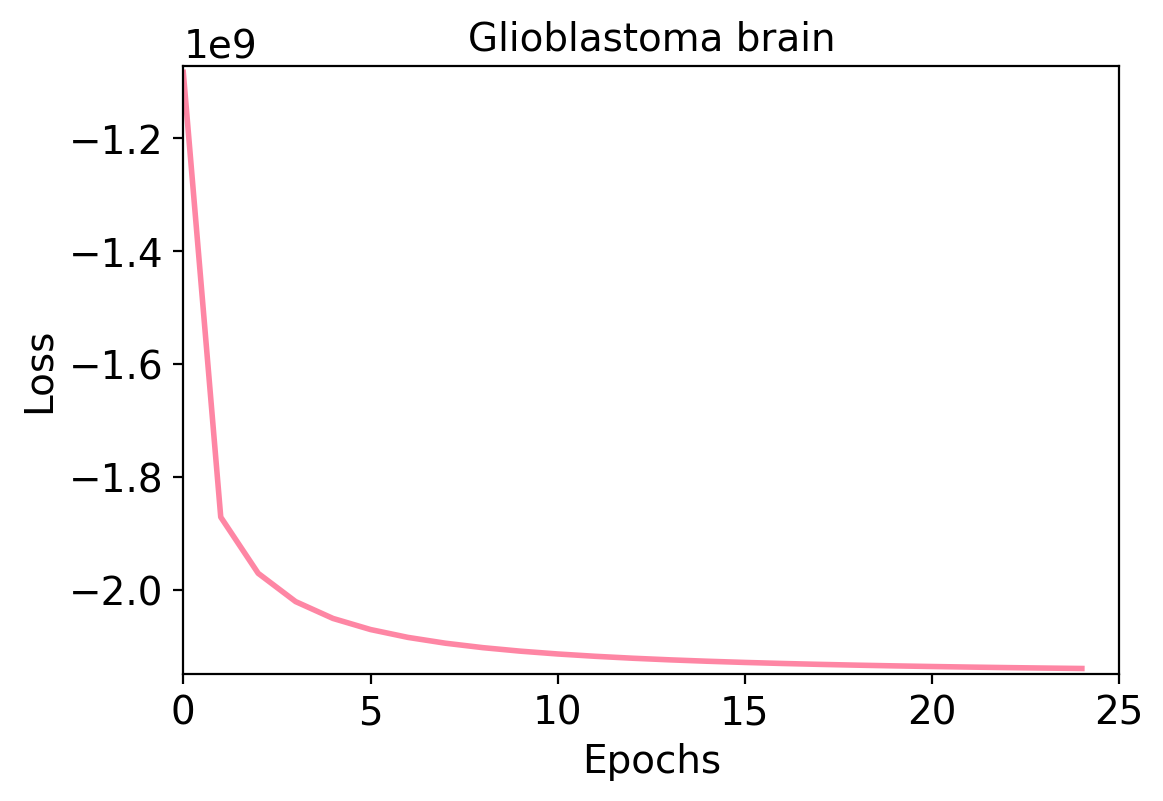

In [28]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses1, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
vmin, vmax = min(min(losses1), 0), max(losses1)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Glioblastoma brain')

[Text(0.5, 0, 'Epochs'), Text(0, 0.5, 'Loss'), Text(0.5, 1.0, 'Healthy brain')]

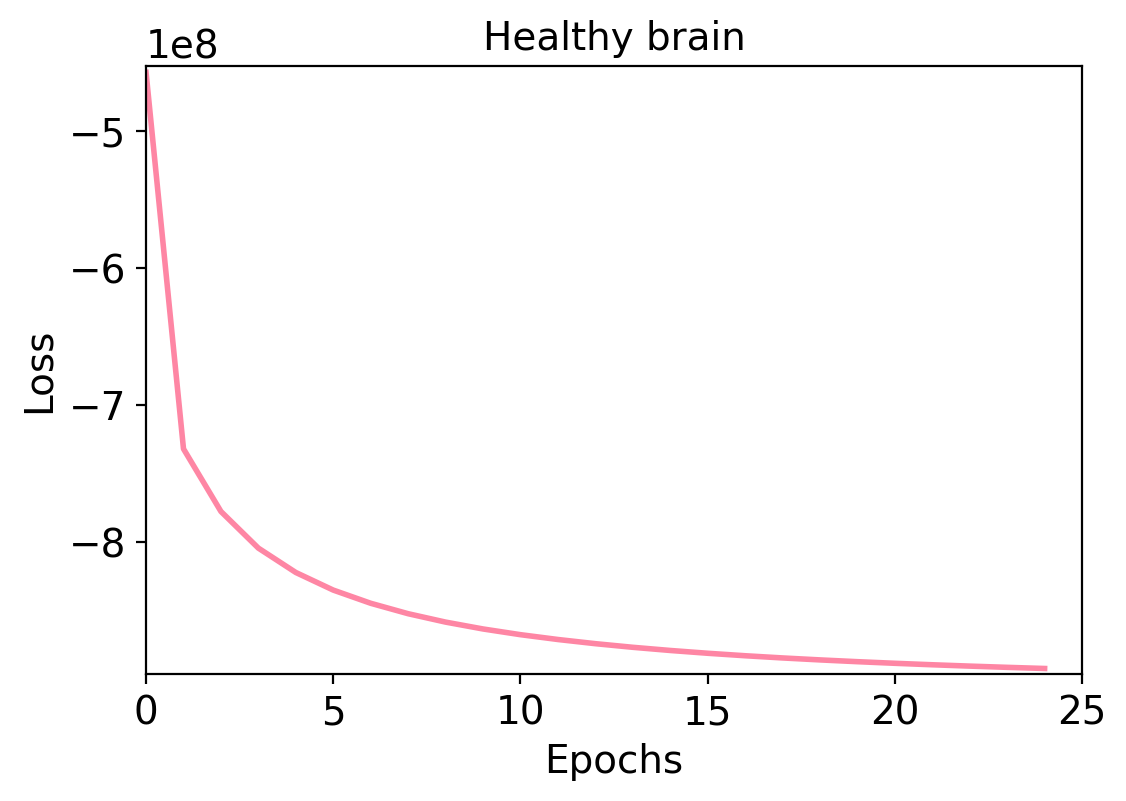

In [29]:
# create the plot for lymph node
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses2, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
vmin, vmax = min(min(losses2), 0), max(losses2)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Healthy brain')

The stable optimization of Celcomen indicates that zmft_scalar has been chosen appropriately.

# Confirm protein localization

In [30]:
# define the gene
genes = avis.var_names
secs = pd.read_table('../ccc/data/external/goids/quickgo_secreted.tsv')['SYMBOL'].unique()
sps = pd.read_table('../ccc/data/external/goids/quickgo_surfaceprotein.tsv')['SYMBOL'].unique()
nons = pd.Index(genes)[(~pd.Index(genes).isin(secs))&(~pd.Index(genes).isin(sps))]
secs = pd.Index(genes).intersection(secs)
sps = pd.Index(genes).intersection(sps)

/loc/scratch/7949135/ipykernel_23377/2855032109.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_23377/2855032109.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_23377/2855032109.py:16: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_23377/2855032109.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed i

3.302425987714723e-17
3.5472332160471856e-70
2.3173479793210794e-30


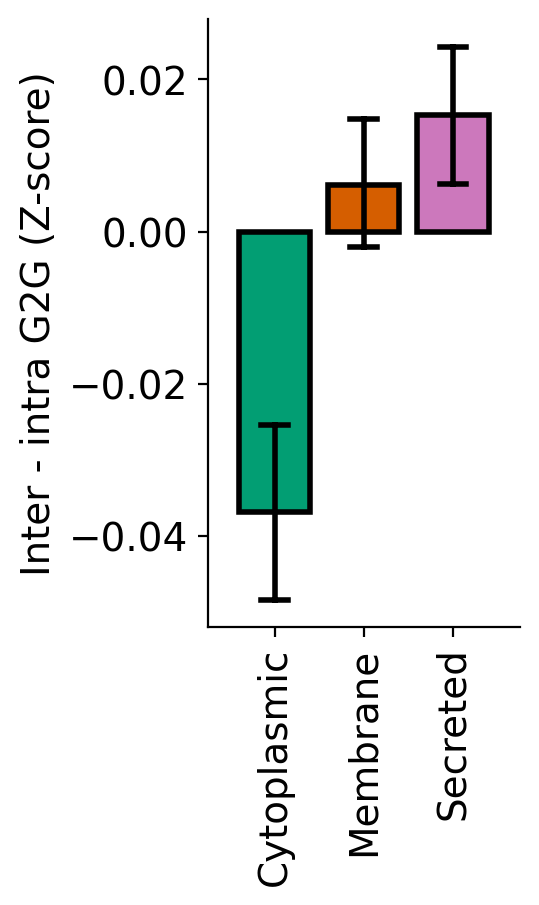

In [31]:
# derive an integrated gene-gene matrix
g2g_intracellular = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_intercellular = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
# derive the values
diffs_secs = (g2g_intercellular.loc[secs, :] - g2g_intracellular.loc[secs, :]).values.flatten()
diffs_sps = (g2g_intercellular.loc[sps, :] - g2g_intracellular.loc[sps, :]).values.flatten()
diffs_nons = (g2g_intercellular.loc[nons, :] - g2g_intracellular.loc[nons, :]).values.flatten()
# assemble them
ys = np.hstack([diffs_secs, diffs_sps, diffs_nons])
ys -= ys.mean()
ys /= ys.std()
xs = np.array(['Secreted']*len(diffs_secs)+['Membrane']*len(diffs_sps)+['Cytoplasmic']*len(diffs_nons))
# create plot
fig, ax = plt.subplots(figsize=[2, 4])
ax.grid(False)
sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
            errcolor='k', edgecolor='k', palette=['#cc78bc','#d55e00','#029e73'][::-1])
ax.set_xlim(-0.75, 2.75)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Inter - intra G2G (Z-score)')
ax.spines[['right', 'top']].set_visible(False)
# derive pvalues
p1 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Membrane'])[1]
p2 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Cytoplasmic'])[1]
p3 = ss.mannwhitneyu(ys[xs == 'Cytoplasmic'], ys[xs == 'Membrane'])[1]
print(p1, p2, p3, sep='\n')

/loc/scratch/7949135/ipykernel_23377/264787739.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_23377/264787739.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_23377/264787739.py:16: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_23377/264787739.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0

1.9490503317332447e-06
2.712115211467086e-12
0.0011900435758523003


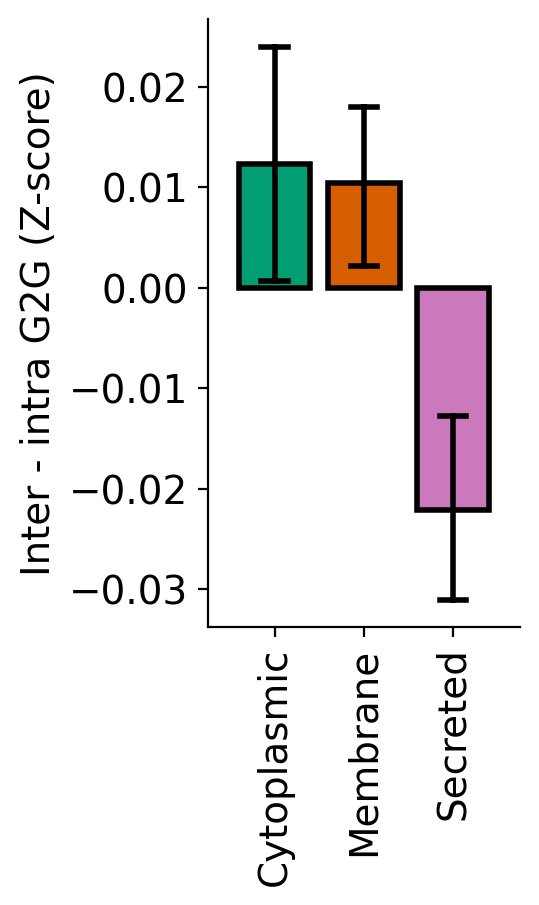

In [32]:
# derive an integrated gene-gene matrix
g2g_intracellular = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_intercellular = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
# derive the values
diffs_secs = (g2g_intercellular.loc[secs, :] - g2g_intracellular.loc[secs, :]).values.flatten()
diffs_sps = (g2g_intercellular.loc[sps, :] - g2g_intracellular.loc[sps, :]).values.flatten()
diffs_nons = (g2g_intercellular.loc[nons, :] - g2g_intracellular.loc[nons, :]).values.flatten()
# assemble them
ys = np.hstack([diffs_secs, diffs_sps, diffs_nons])
ys -= ys.mean()
ys /= ys.std()
xs = np.array(['Secreted']*len(diffs_secs)+['Membrane']*len(diffs_sps)+['Cytoplasmic']*len(diffs_nons))
# create plot
fig, ax = plt.subplots(figsize=[2, 4])
ax.grid(False)
sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
            errcolor='k', edgecolor='k', palette=['#cc78bc','#d55e00','#029e73'][::-1])
ax.set_xlim(-0.75, 2.75)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Inter - intra G2G (Z-score)')
ax.spines[['right', 'top']].set_visible(False)
# derive pvalues
p1 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Membrane'])[1]
p2 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Cytoplasmic'])[1]
p3 = ss.mannwhitneyu(ys[xs == 'Cytoplasmic'], ys[xs == 'Membrane'])[1]
print(p1, p2, p3, sep='\n')

# Interpret gene interaction matrices (intracellular)

In [33]:
# compare intracellular
g2g_intra1 = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_intra2 = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)

In [34]:
from scipy.cluster.hierarchy import linkage, fcluster
# compute fetal - adult
g2g_diff = g2g_intra1 - g2g_intra2
# compute linkages
Z = linkage(g2g_diff, method='ward')

In [35]:
from sklearn.metrics import silhouette_score
# choose an optimal clustering
df_scores = pd.DataFrame(columns=['t','score','min_size','max_size','avg_size','median_size'])
for t in range(3, 20+1):
    clusters = fcluster(Z, criterion='maxclust', t=t)
    score = silhouette_score(g2g_diff, clusters)
    counts = pd.Series(clusters).value_counts()
    df_scores.loc[df_scores.shape[0]] = t, score, min(counts), max(counts), np.mean(counts), np.median(counts)

Text(0, 0.5, 'Min cluster size (dashed black)')

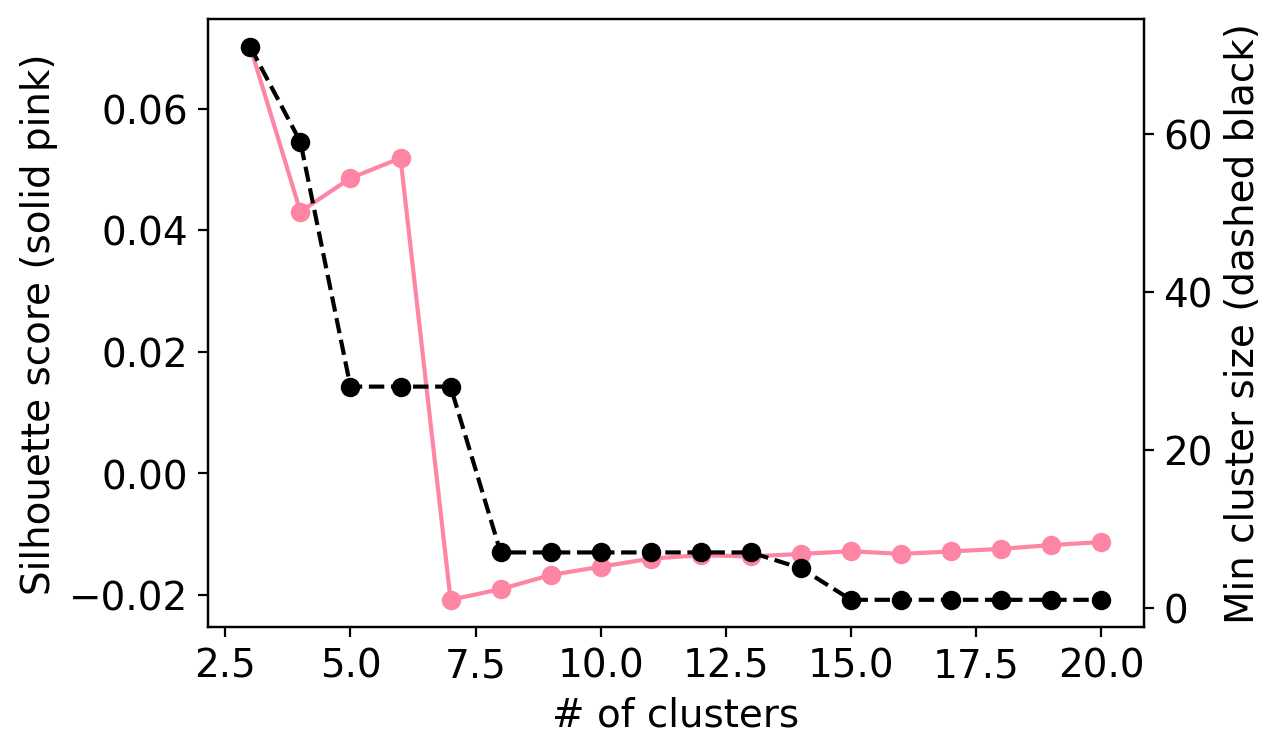

In [36]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['min_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Min cluster size (dashed black)')

Text(0, 0.5, 'Max cluster size (dashed black)')

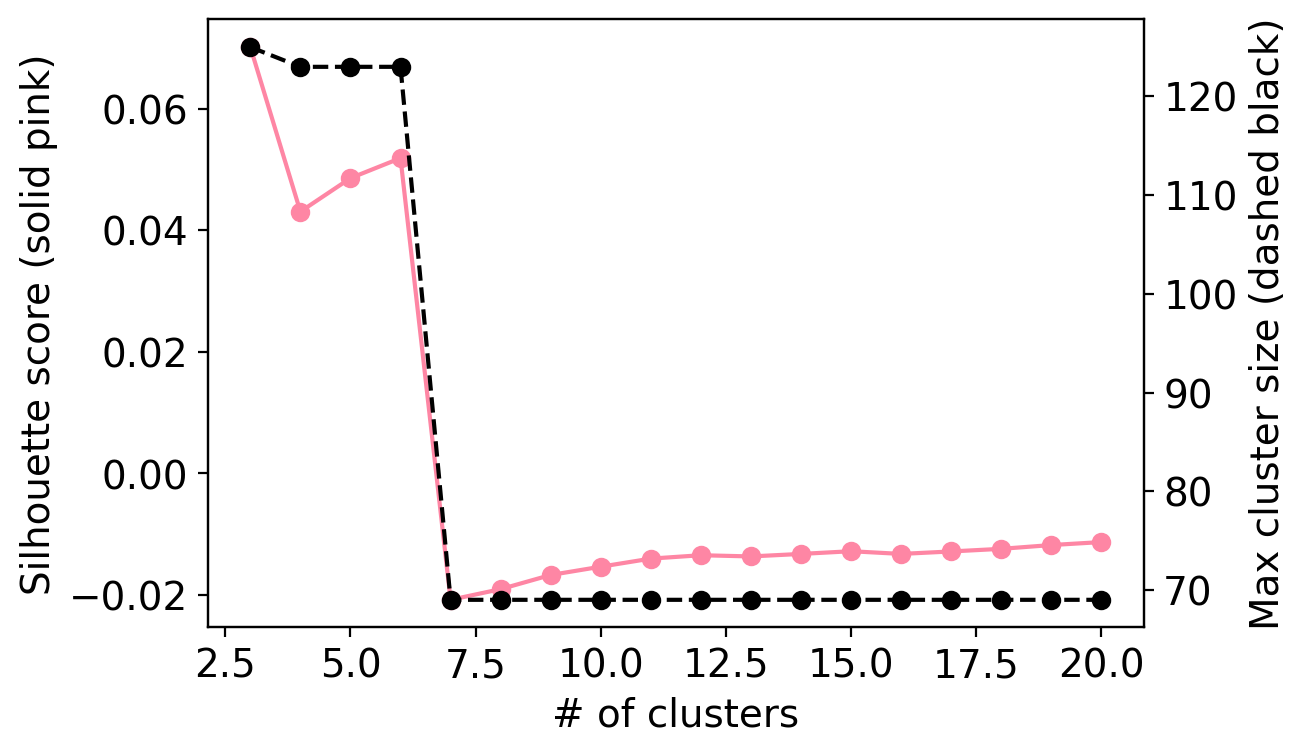

In [37]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['max_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Max cluster size (dashed black)')

Text(0, 0.5, 'Mean cluster size (dashed black)')

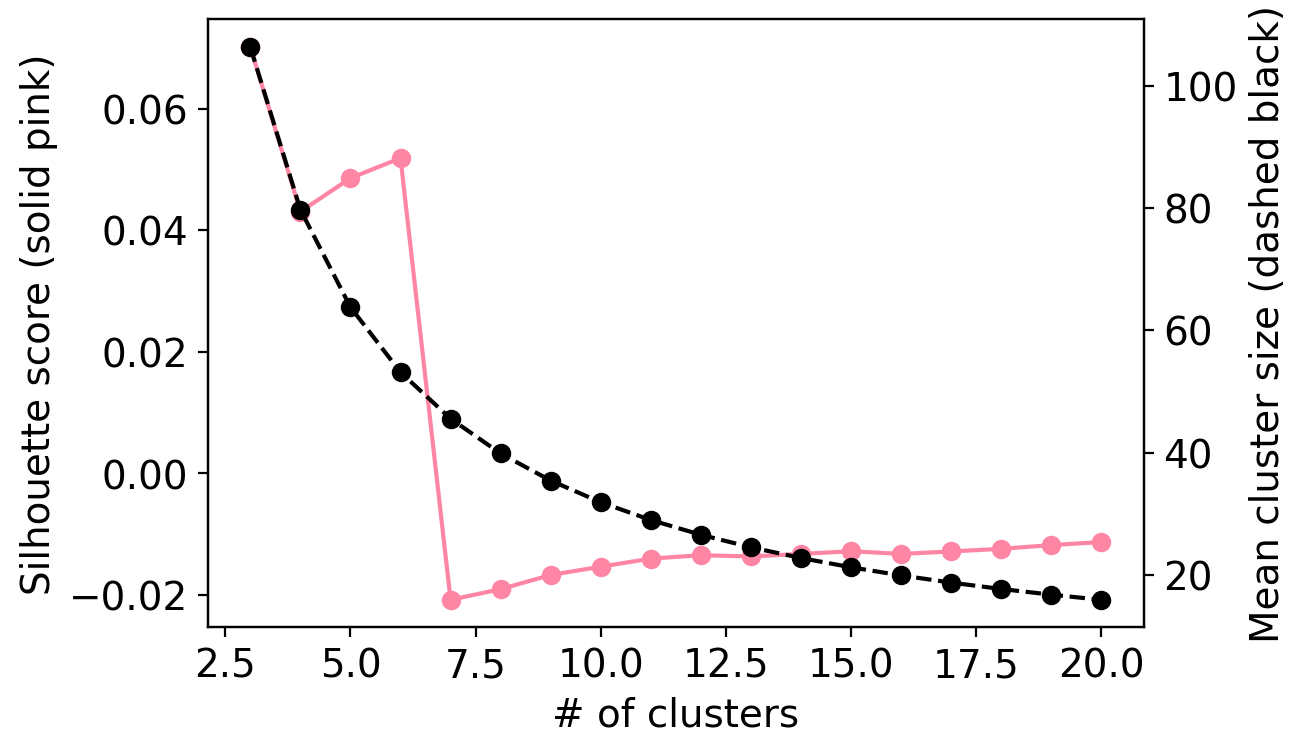

In [38]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['avg_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Mean cluster size (dashed black)')

Text(0, 0.5, 'Median cluster size (dashed black)')

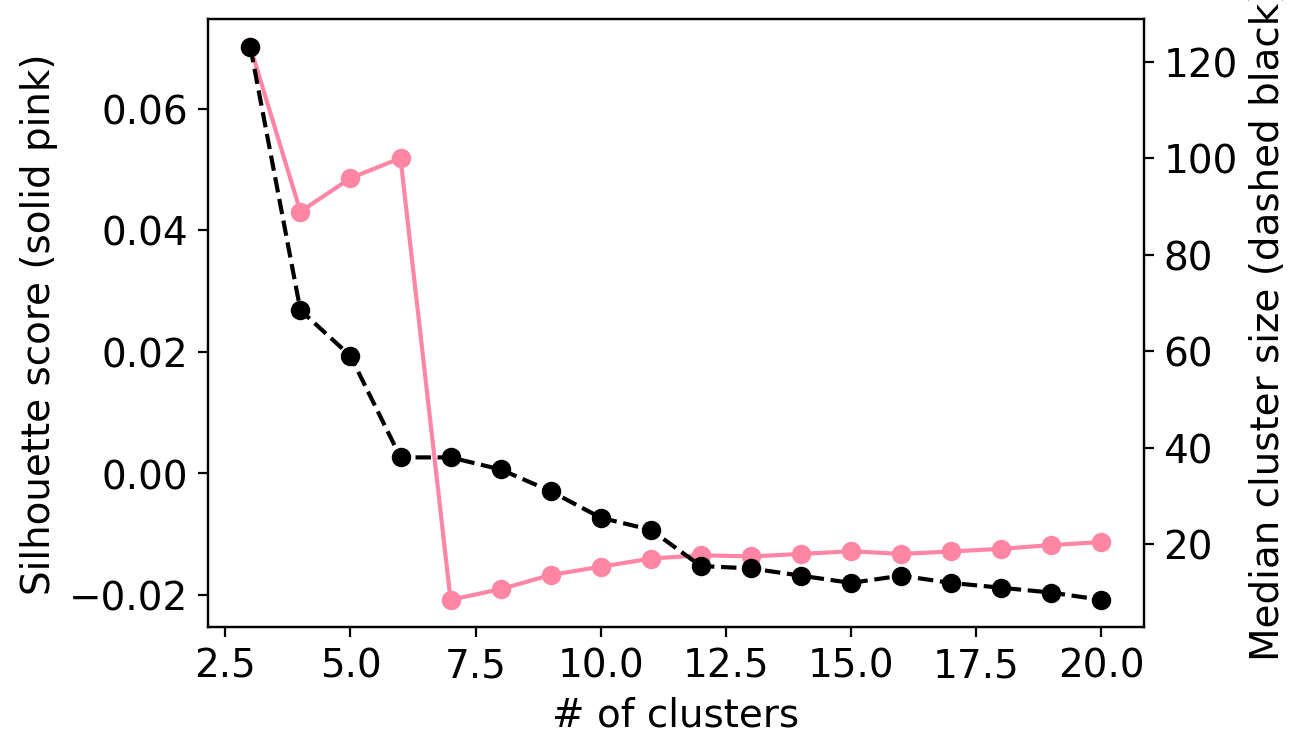

In [40]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['median_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Median cluster size (dashed black)')

[Text(0.5, 0, 'Interaction difference cluster')]

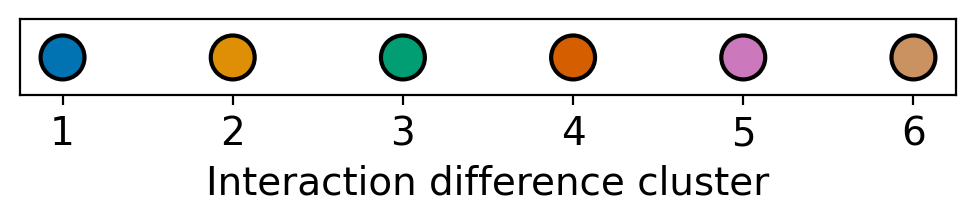

In [41]:
# create the colors and a legend
t = 6
clusters = pd.Series(fcluster(Z, criterion='maxclust', t=t), index=genes)
palette = sns.color_palette('colorblind', t).as_hex()
c2c = {idx+1:c for idx, c in enumerate(palette)}
# plot the legend
fig, ax = plt.subplots(figsize=[6, 0.5]); ax.grid(False)
ax.scatter(range(1, t+1), [0]*t, color=palette, s=2.5e2, edgecolor='k', linewidth=1.5)
ax.set_yticks([]); ax.set_xticks(range(1, t+1)); ax.set_xticklabels(range(1, t+1))
ax.set(xlabel='Interaction difference cluster')

[]

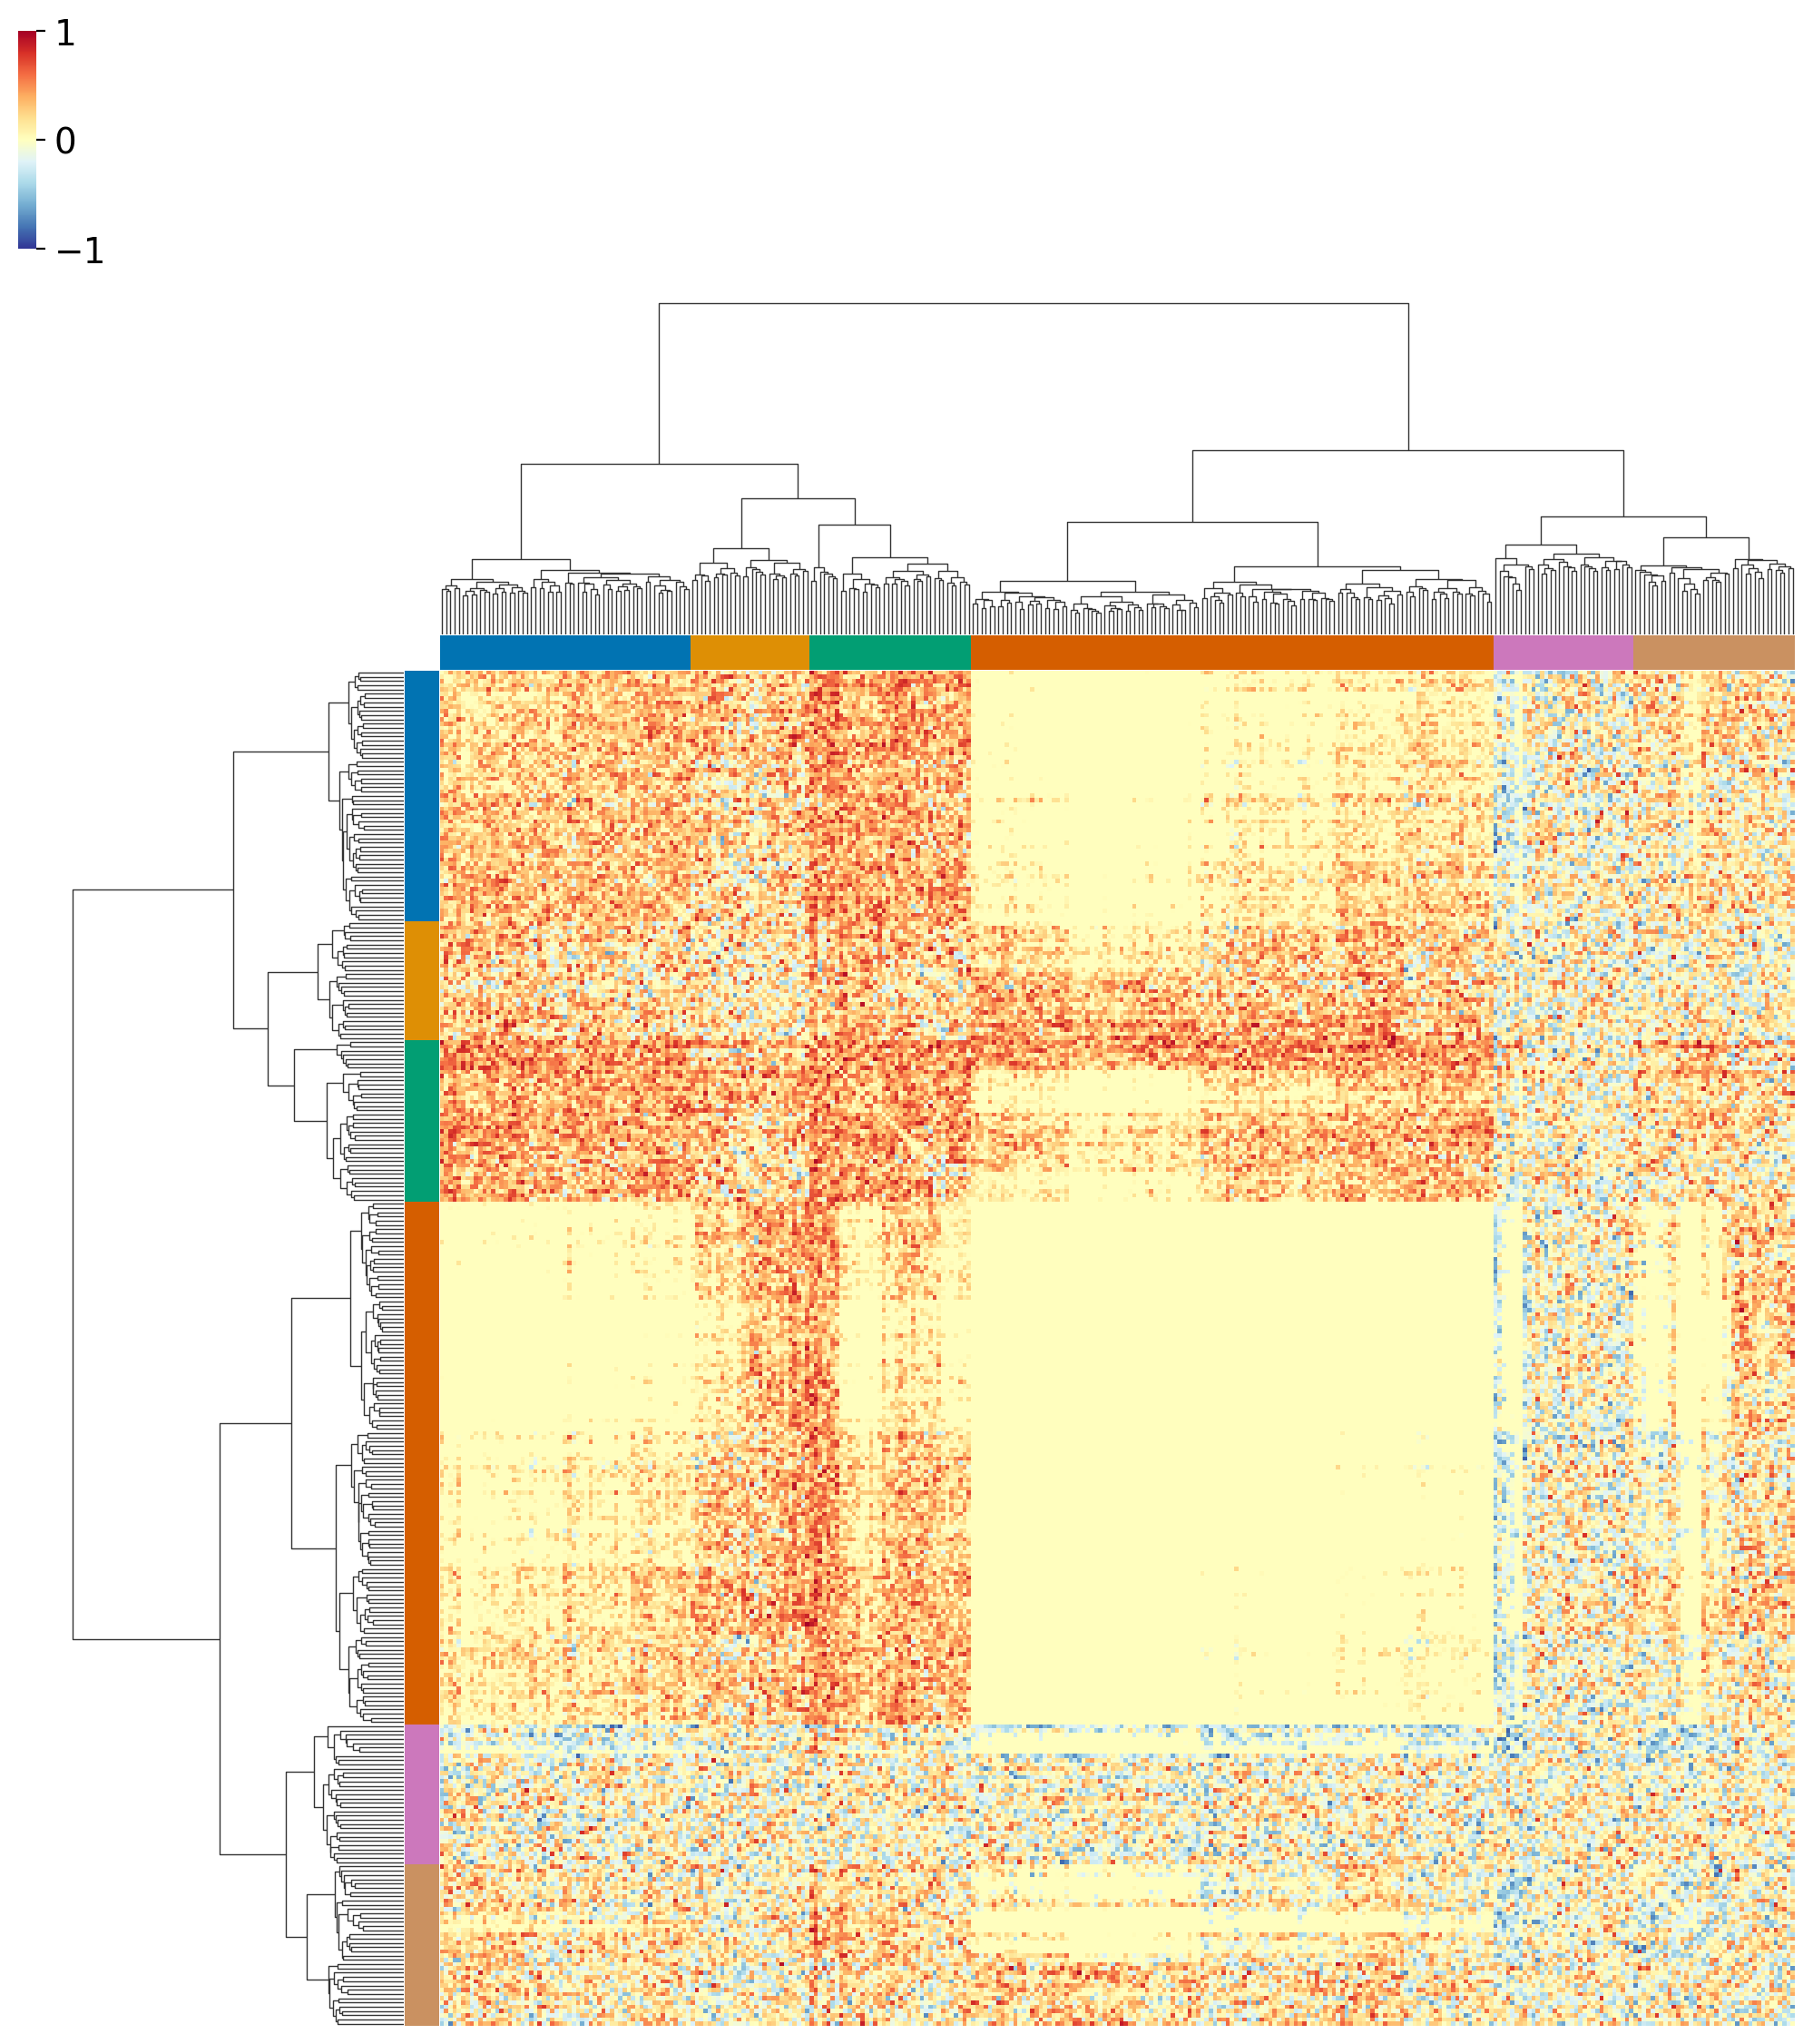

In [42]:
# show the differences
colors = clusters.map(c2c)
g = sns.clustermap(g2g_diff, vmin=-1, vmax=1, cmap='RdYlBu_r',
                   method='ward', cbar_pos=(0, 1, .01, .12), 
                   row_linkage=Z, col_linkage=Z, colors_ratio=(.02),
                   row_colors=colors, col_colors=colors,
                   xticklabels=0, yticklabels=0)
g.ax_heatmap.grid(False); g.ax_cbar.grid(False)
g.ax_col_colors.grid(False); g.ax_col_colors.set_yticks([])
g.ax_row_colors.grid(False); g.ax_row_colors.set_xticks([])

In [43]:
# assemble the non-symmetric non-identical interactions
datas = []
for cluster in clusters.unique():
    idxs = clusters.index[clusters == cluster]
    # get non-identical
    values = g2g_diff.loc[idxs, idxs].values
    flat = []
    for idx in range(values.shape[1]-1):
        flat.extend(values[idx, idx+1:].tolist())
    data = pd.DataFrame(flat, columns=['value'])
    data['cluster'] = cluster
    datas.append(data)
data = pd.concat(datas, axis=0)

/loc/scratch/7949135/ipykernel_23377/2496187654.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_23377/2496187654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_23377/2496187654.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_23377/2496187654.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15

KW p=0.000e+00


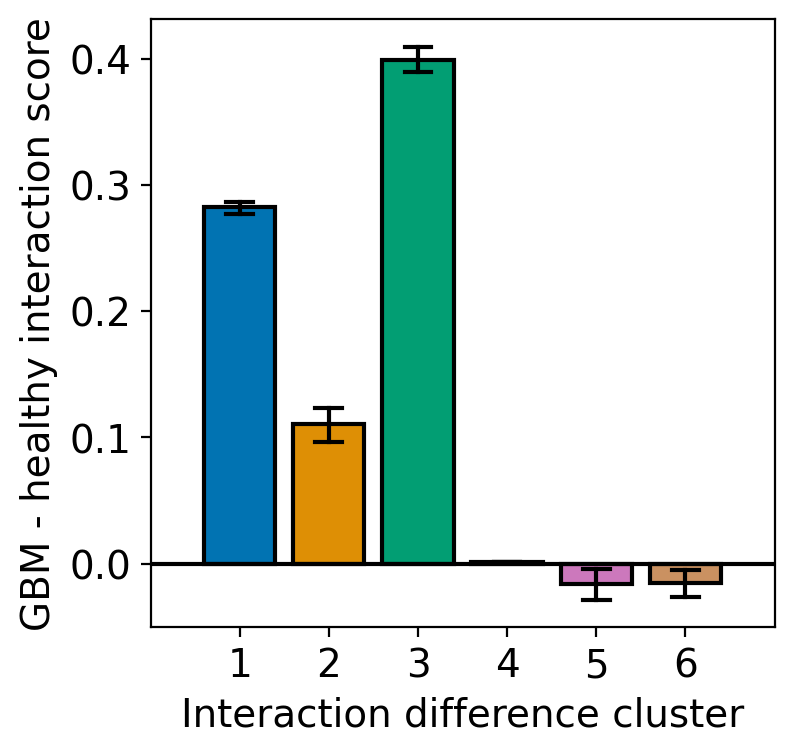

In [44]:
# identify differences with KW
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
            ci=68, errwidth=1.5, capsize=0.3, errcolor='k', saturation=1)
ax.plot([-1, t], [0]*2, color='k'); ax.set_xlim(-1, t)
ax.set(xlabel='Interaction difference cluster', ylabel='GBM - healthy interaction score')
print('KW p=%.3e' % ss.kruskal(*[data['value'] for data in datas])[1])

In [52]:
# # investigate 3, 4, 5
# for x in clusters.index[clusters == 5]:
#     print(x)

/loc/scratch/7949135/ipykernel_23377/2720429913.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 5')

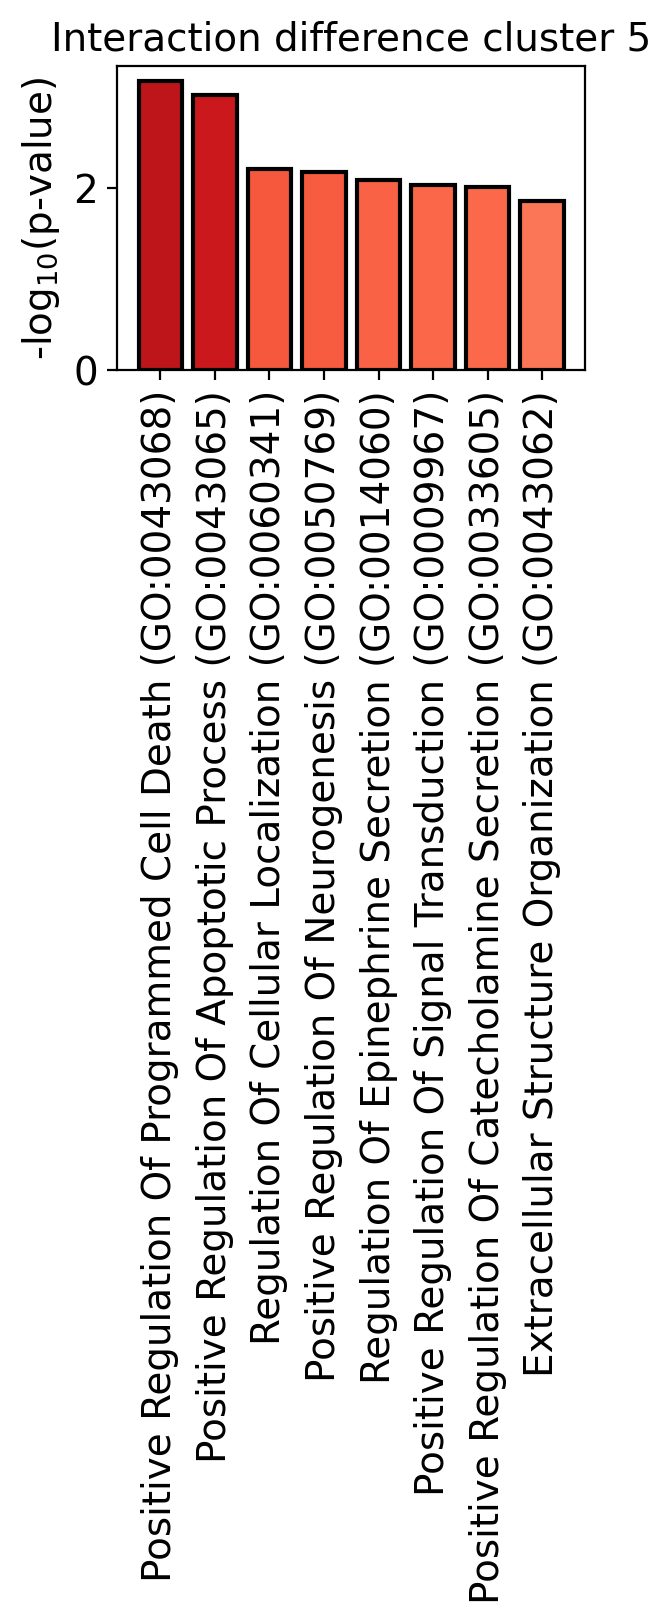

In [54]:
from matplotlib.cm import get_cmap
from matplotlib.colors import to_hex
# read in the enrichments (for non-enrichments)
pathways = '''Positive Regulation Of Programmed Cell Death (GO:0043068)
Positive Regulation Of Apoptotic Process (GO:0043065)
Regulation Of Cellular Localization (GO:0060341)
Positive Regulation Of Neurogenesis (GO:0050769)
Regulation Of Epinephrine Secretion (GO:0014060)
Positive Regulation Of Signal Transduction (GO:0009967)
Positive Regulation Of Catecholamine Secretion (GO:0033605)
Extracellular Structure Organization (GO:0043062)'''.split('\n')
pvals = [float(x) for x in '''6.80E-04
9.77E-04
0.006278388
0.006795357
0.008223548
0.00945419
0.009860378
0.013919756'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 5')

/loc/scratch/7949135/ipykernel_23377/180251893.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 4')

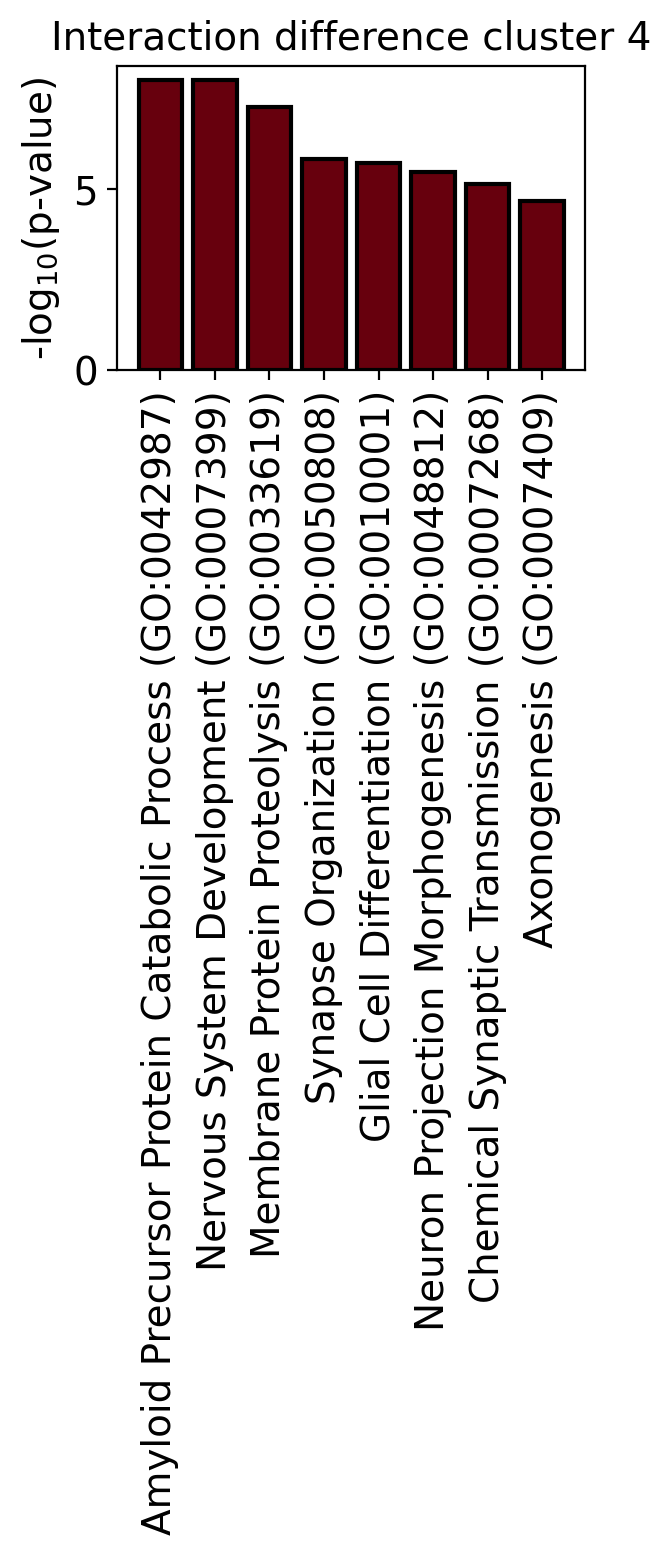

In [57]:
# read in the enrichments (for non-enrichments)
pathways = '''Amyloid Precursor Protein Catabolic Process (GO:0042987)
Nervous System Development (GO:0007399)
Membrane Protein Proteolysis (GO:0033619)
Synapse Organization (GO:0050808)
Glial Cell Differentiation (GO:0010001)
Neuron Projection Morphogenesis (GO:0048812)
Chemical Synaptic Transmission (GO:0007268)
Axonogenesis (GO:0007409)'''.split('\n')
pvals = [float(x) for x in '''1.00E-08
1.01E-08
5.59E-08
1.50E-06
1.96E-06
3.38E-06
7.37E-06
2.15E-05'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 4')

/loc/scratch/7949135/ipykernel_23377/1474987928.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 3')

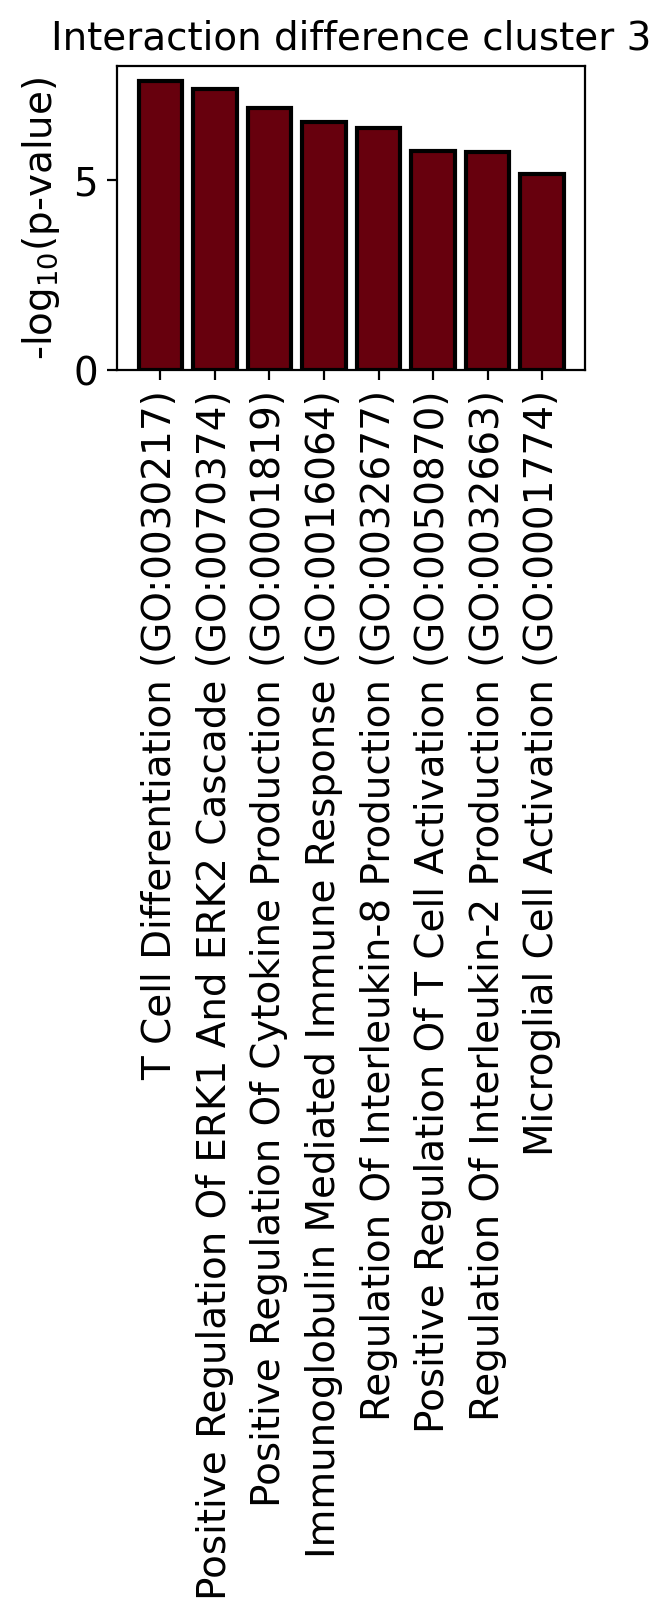

In [58]:
# read in the enrichments (for non-enrichments)
pathways = '''T Cell Differentiation (GO:0030217)
Positive Regulation Of ERK1 And ERK2 Cascade (GO:0070374)
Positive Regulation Of Cytokine Production (GO:0001819)
Immunoglobulin Mediated Immune Response (GO:0016064)
Regulation Of Interleukin-8 Production (GO:0032677)
Positive Regulation Of T Cell Activation (GO:0050870)
Regulation Of Interleukin-2 Production (GO:0032663)
Microglial Cell Activation (GO:0001774)'''.split('\n')
pvals = [float(x) for x in '''2.44E-08
4.08E-08
1.27E-07
2.93E-07
4.35E-07
1.74E-06
1.86E-06
7.05E-06'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 3')

# Interpret gene interaction matrices (intercellular)

In [59]:
# compare intracellular
g2g_inter1 = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_inter2 = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)

In [60]:
from scipy.cluster.hierarchy import linkage, fcluster
# compute fetal - adult
g2g_diff = g2g_inter1 - g2g_inter2
# compute linkages
Z = linkage(g2g_diff, method='ward')

In [61]:
from sklearn.metrics import silhouette_score
# choose an optimal clustering
df_scores = pd.DataFrame(columns=['t','score','min_size','max_size','avg_size','median_size'])
for t in range(3, 20+1):
    clusters = fcluster(Z, criterion='maxclust', t=t)
    score = silhouette_score(g2g_diff, clusters)
    counts = pd.Series(clusters).value_counts()
    df_scores.loc[df_scores.shape[0]] = t, score, min(counts), max(counts), np.mean(counts), np.median(counts)

Text(0, 0.5, 'Min cluster size (dashed black)')

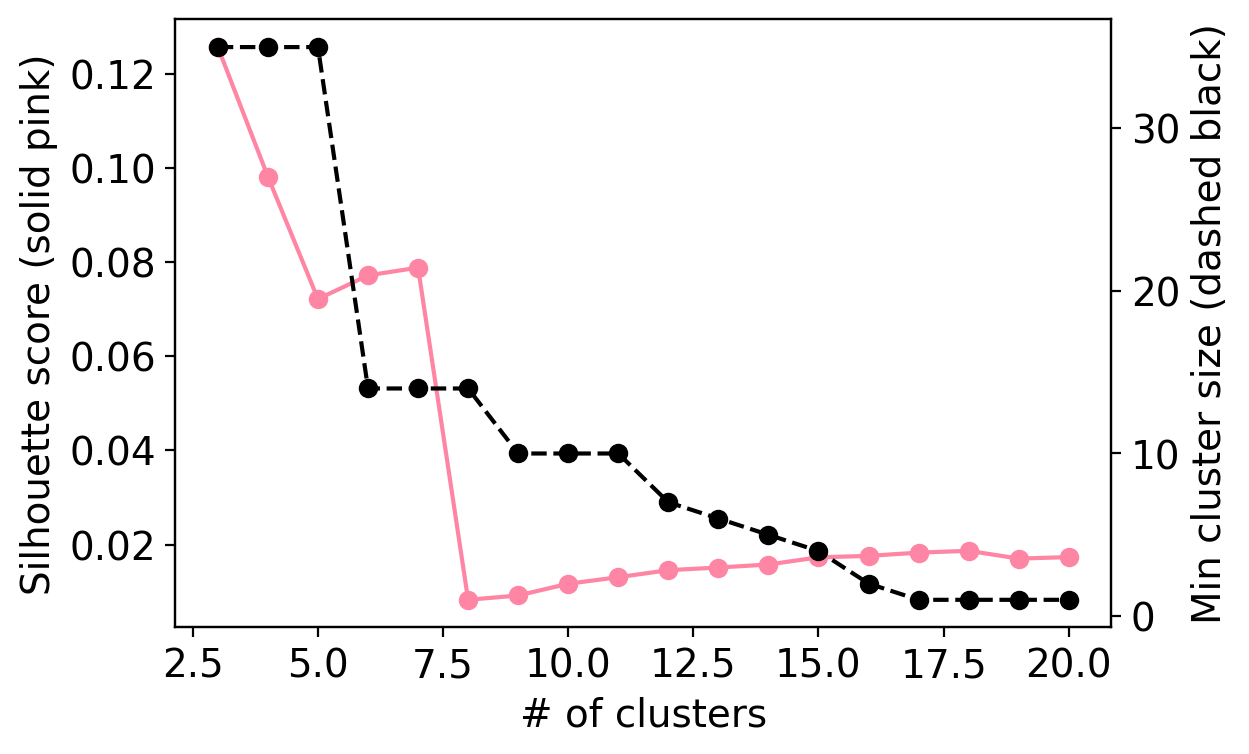

In [62]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['min_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Min cluster size (dashed black)')

Text(0, 0.5, 'Max cluster size (dashed black)')

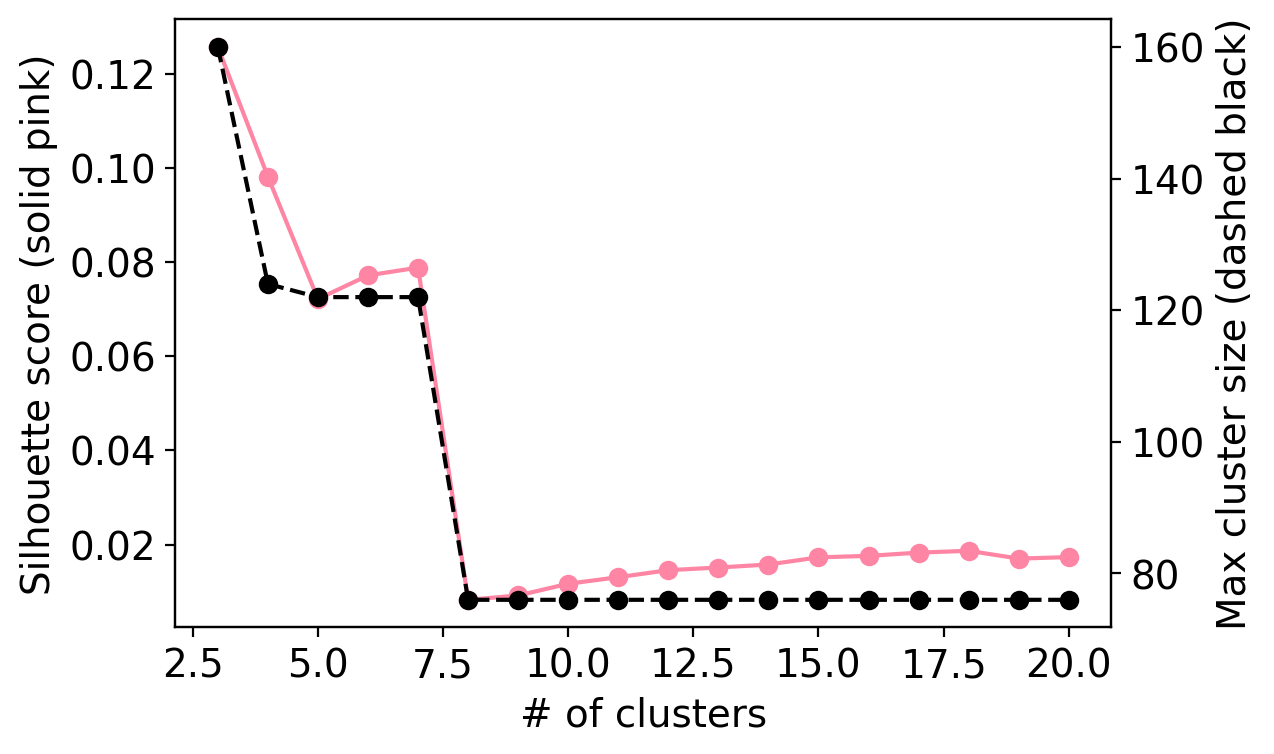

In [63]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['max_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Max cluster size (dashed black)')

Text(0, 0.5, 'Mean cluster size (dashed black)')

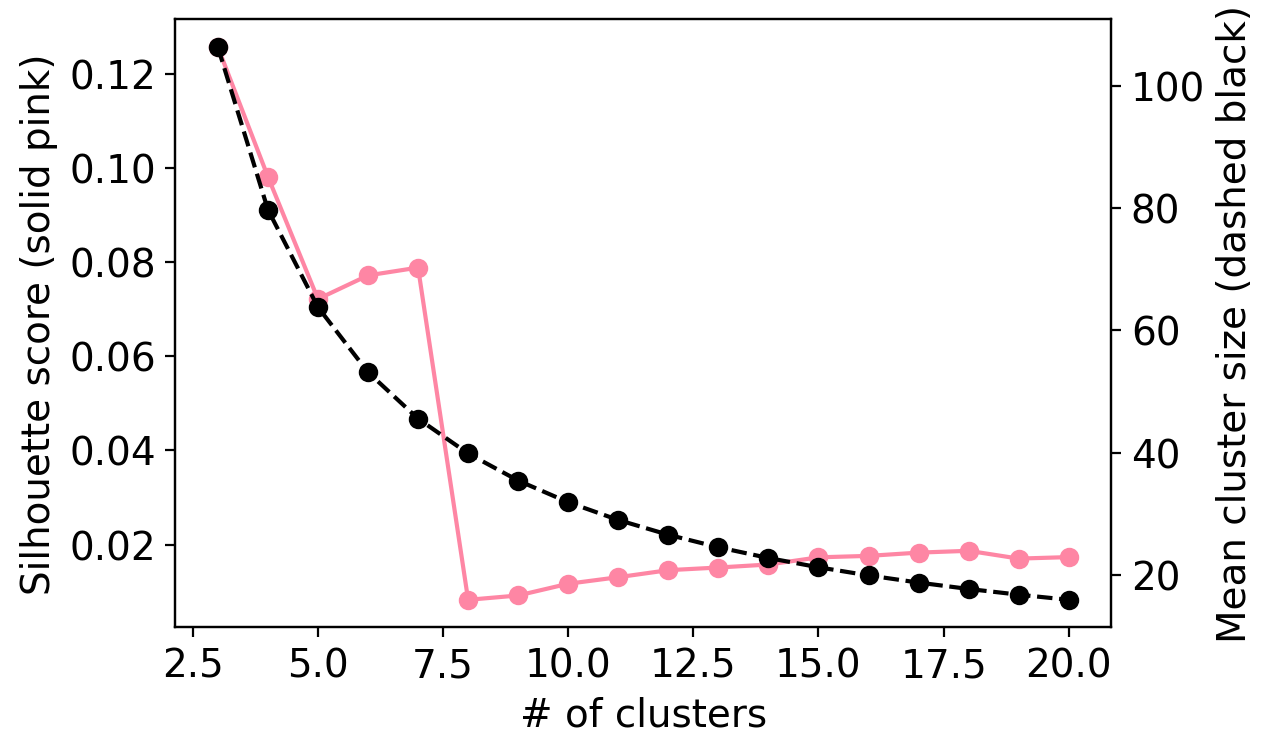

In [64]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['avg_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Mean cluster size (dashed black)')

Text(0, 0.5, 'Median cluster size (dashed black)')

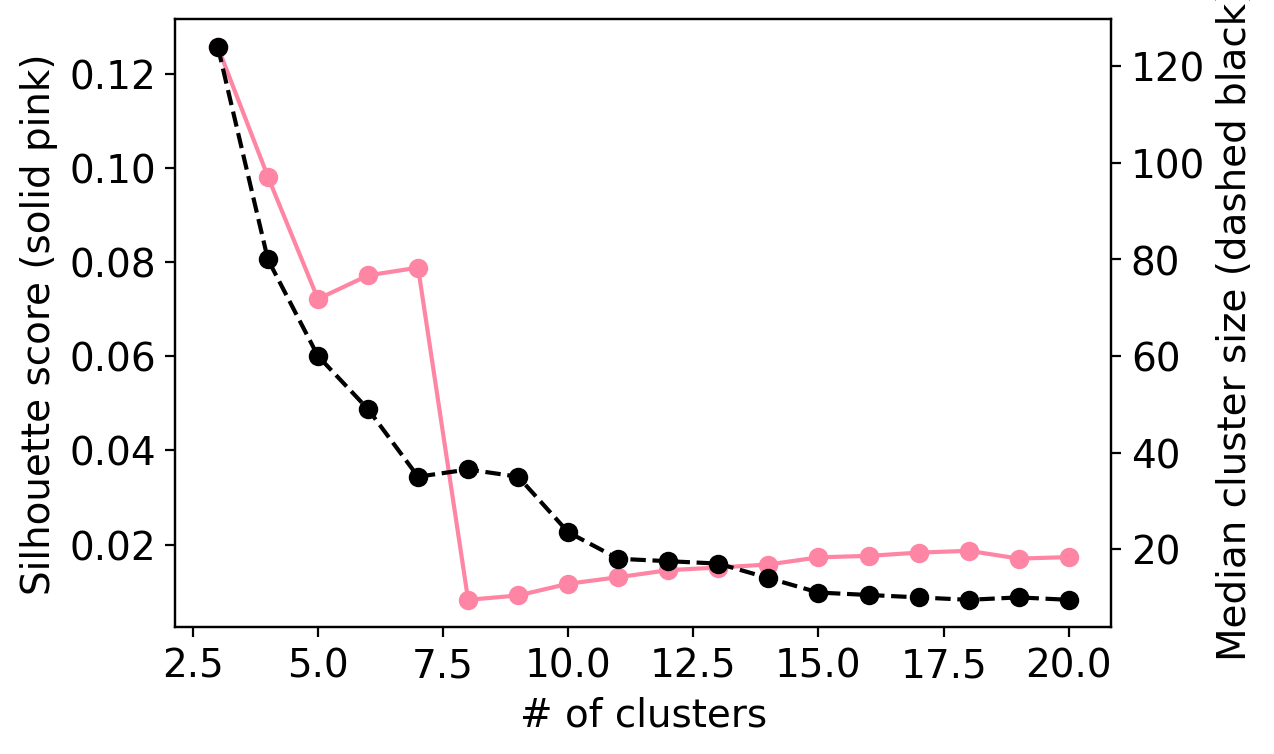

In [65]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['median_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Median cluster size (dashed black)')

[Text(0.5, 0, 'Interaction difference cluster')]

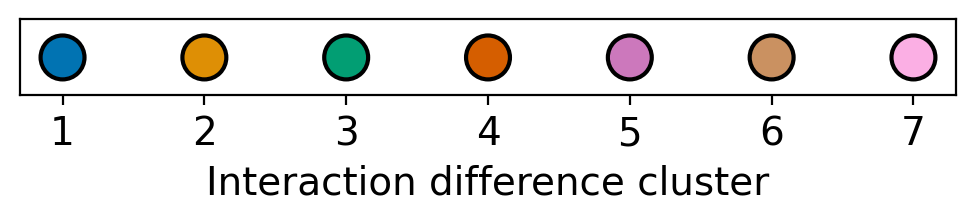

In [66]:
# create the colors and a legend
t = 7
clusters = pd.Series(fcluster(Z, criterion='maxclust', t=t), index=genes)
palette = sns.color_palette('colorblind', t).as_hex()
c2c = {idx+1:c for idx, c in enumerate(palette)}
# plot the legend
fig, ax = plt.subplots(figsize=[6, 0.5]); ax.grid(False)
ax.scatter(range(1, t+1), [0]*t, color=palette, s=2.5e2, edgecolor='k', linewidth=1.5)
ax.set_yticks([]); ax.set_xticks(range(1, t+1)); ax.set_xticklabels(range(1, t+1))
ax.set(xlabel='Interaction difference cluster')

[]

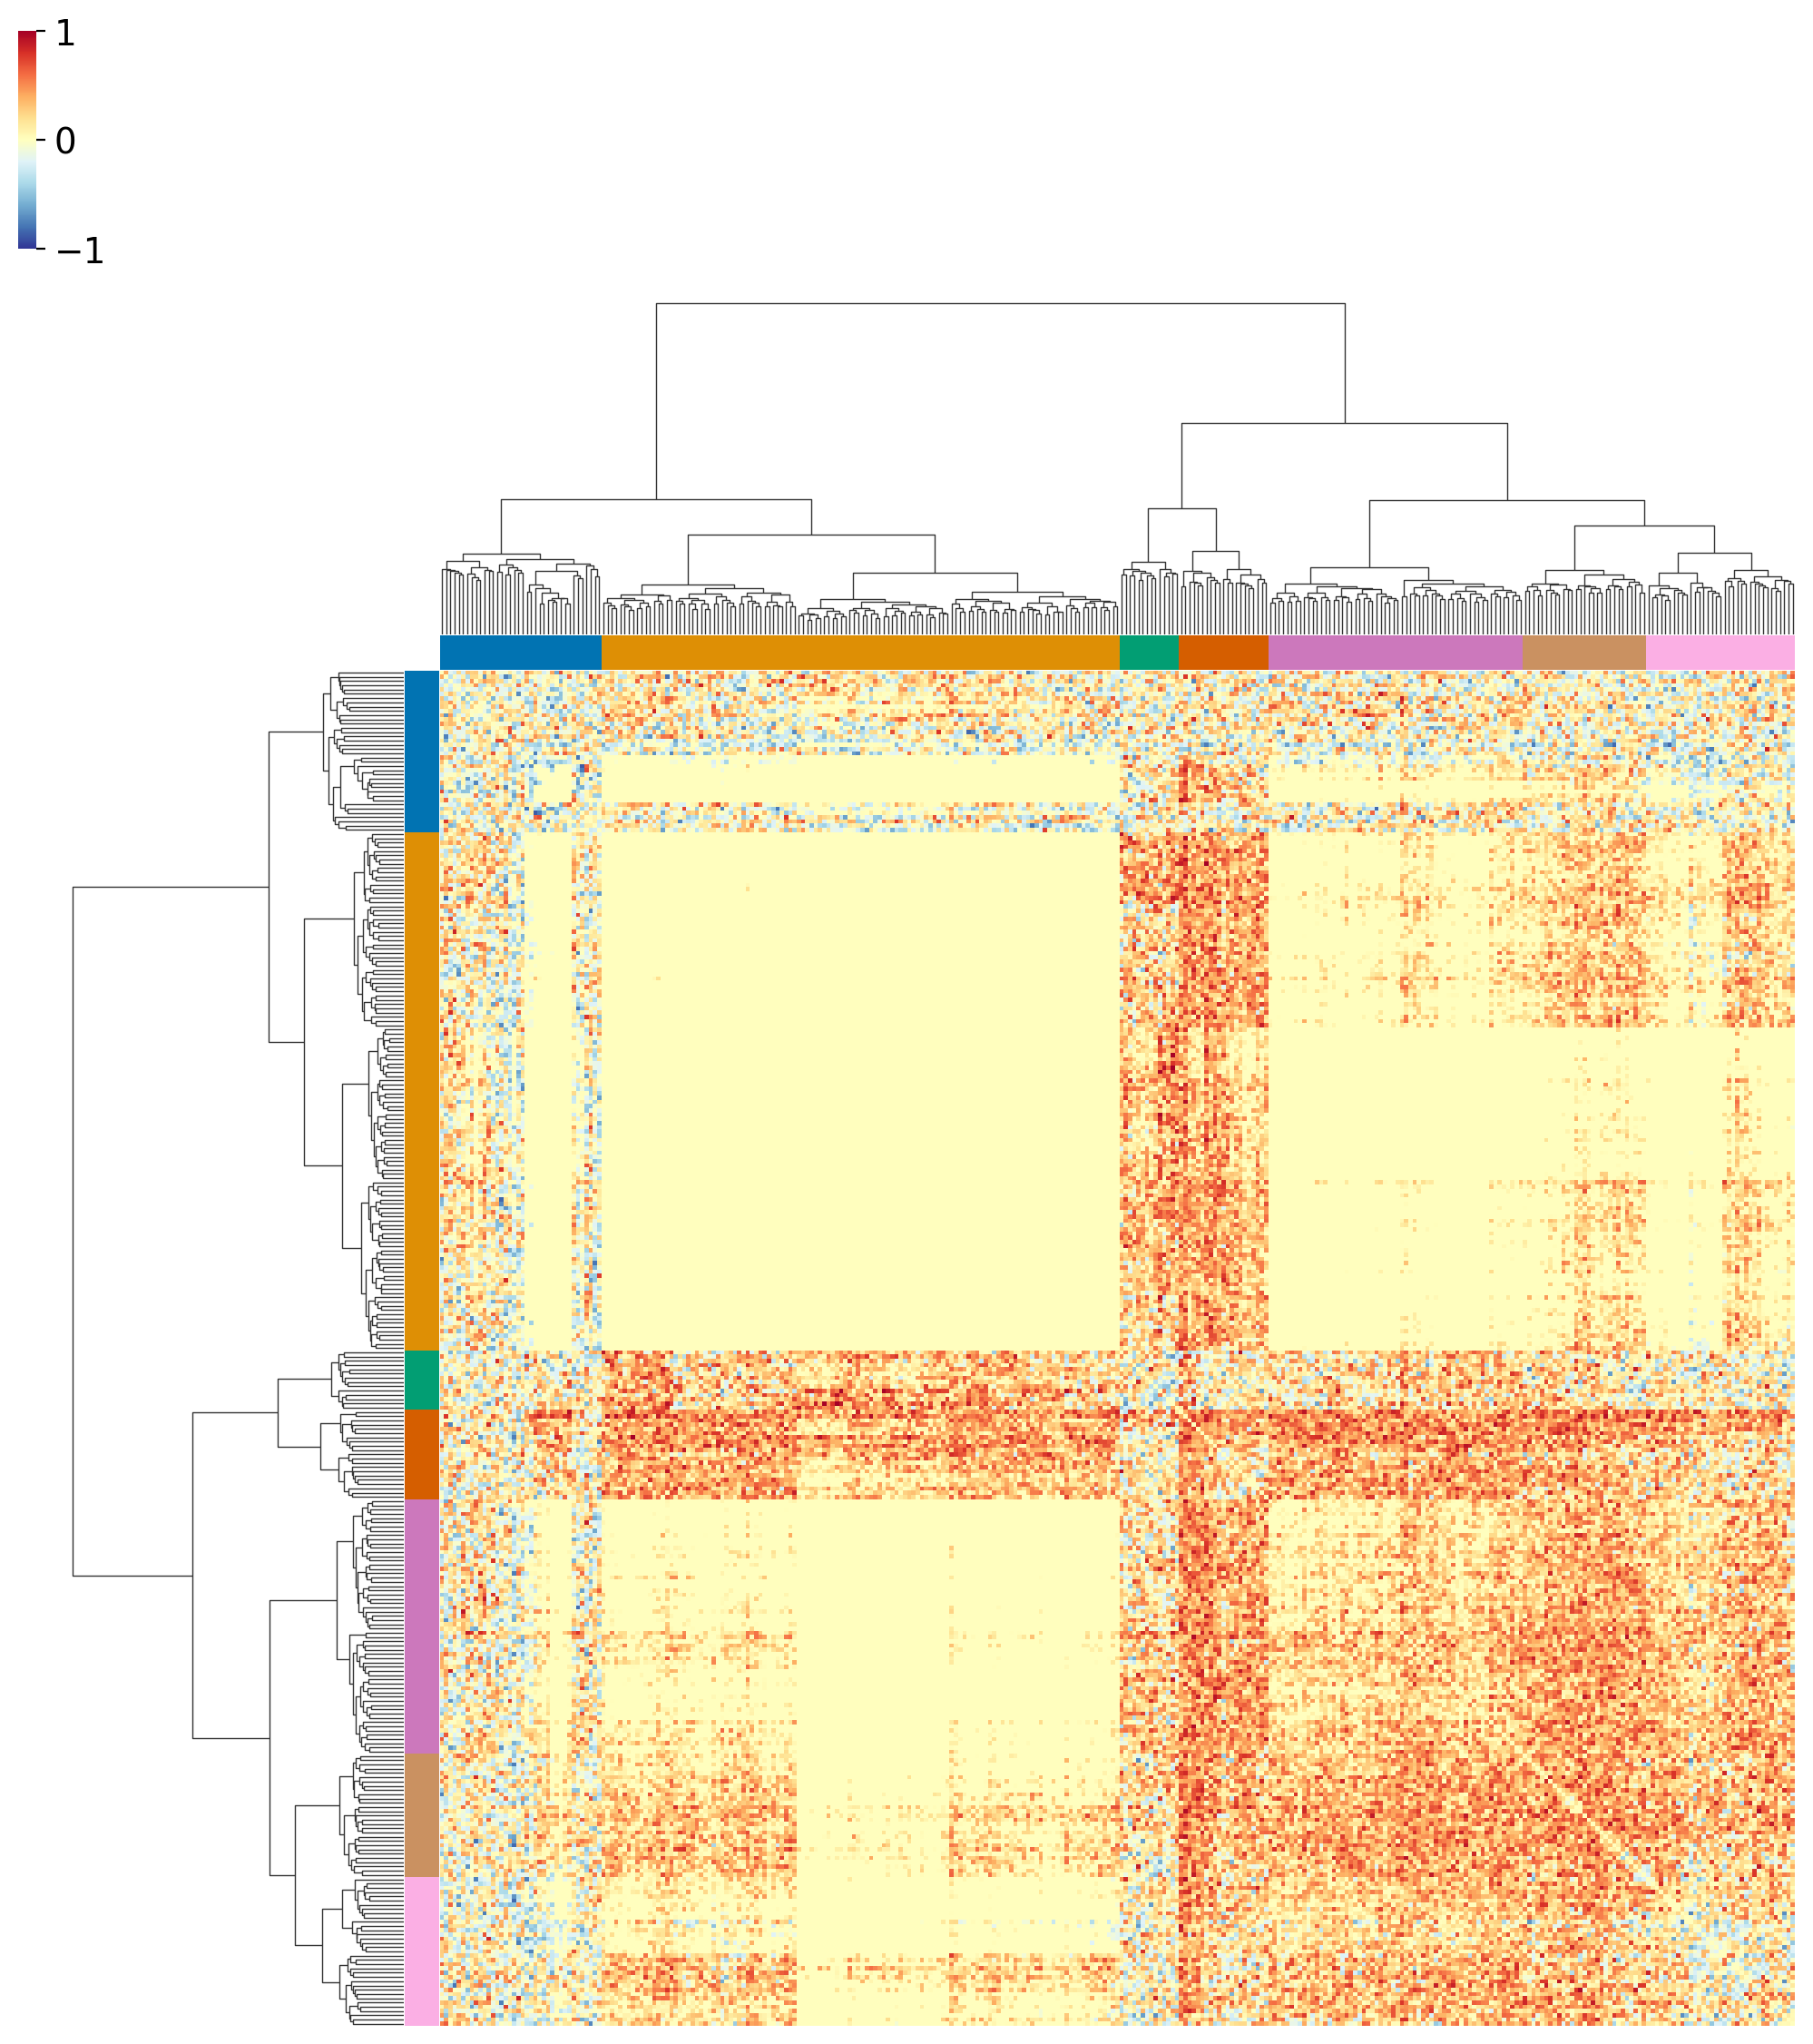

In [67]:
# show the differences
colors = clusters.map(c2c)
g = sns.clustermap(g2g_diff, vmin=-1, vmax=1, cmap='RdYlBu_r',
                   method='ward', cbar_pos=(0, 1, .01, .12), 
                   row_linkage=Z, col_linkage=Z, colors_ratio=(.02),
                   row_colors=colors, col_colors=colors,
                   xticklabels=0, yticklabels=0)
g.ax_heatmap.grid(False); g.ax_cbar.grid(False)
g.ax_col_colors.grid(False); g.ax_col_colors.set_yticks([])
g.ax_row_colors.grid(False); g.ax_row_colors.set_xticks([])

In [68]:
# assemble the non-symmetric non-identical interactions
datas = []
for cluster in clusters.unique():
    idxs = clusters.index[clusters == cluster]
    # get non-identical
    values = g2g_diff.loc[idxs, idxs].values
    flat = []
    for idx in range(values.shape[1]-1):
        flat.extend(values[idx, idx+1:].tolist())
    data = pd.DataFrame(flat, columns=['value'])
    data['cluster'] = cluster
    datas.append(data)
data = pd.concat(datas, axis=0)

/loc/scratch/7949135/ipykernel_23377/2496187654.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_23377/2496187654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_23377/2496187654.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_23377/2496187654.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15

KW p=0.000e+00


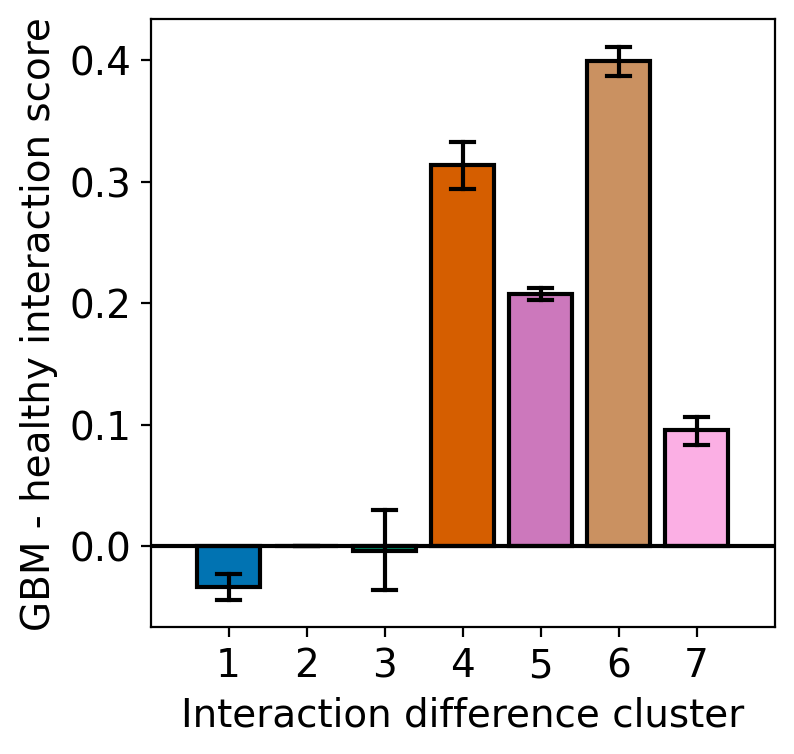

In [69]:
# identify differences with KW
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
            ci=68, errwidth=1.5, capsize=0.3, errcolor='k', saturation=1)
ax.plot([-1, t], [0]*2, color='k'); ax.set_xlim(-1, t)
ax.set(xlabel='Interaction difference cluster', ylabel='GBM - healthy interaction score')
print('KW p=%.3e' % ss.kruskal(*[data['value'] for data in datas])[1])

In [73]:
# # investigate 1, 2, 6
# for x in clusters.index[clusters == 6]:
#     print(x)

/loc/scratch/7949135/ipykernel_23377/167002970.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 6')

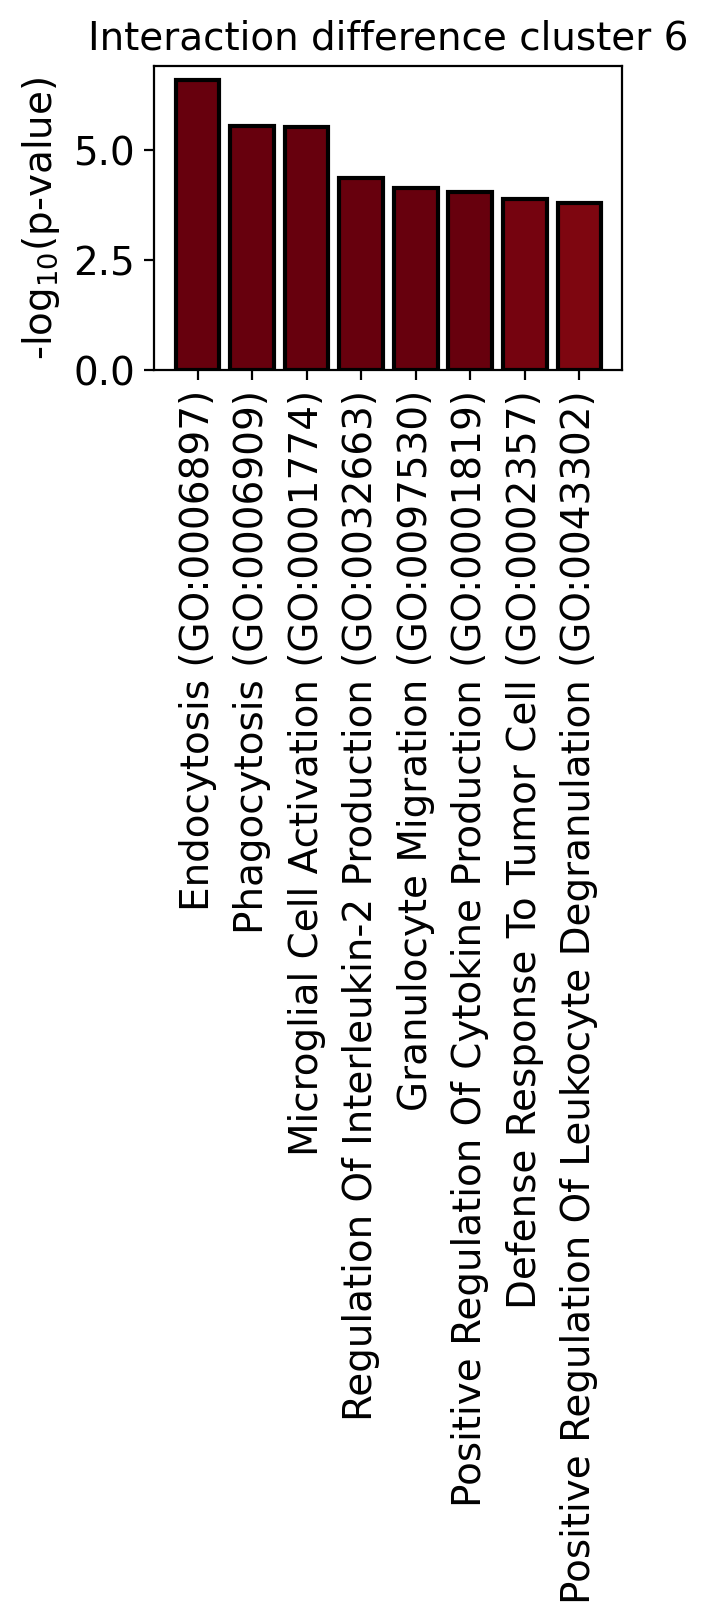

In [74]:
from matplotlib.cm import get_cmap
from matplotlib.colors import to_hex
# read in the enrichments (for non-enrichments)
pathways = '''Endocytosis (GO:0006897)
Phagocytosis (GO:0006909)
Microglial Cell Activation (GO:0001774)
Regulation Of Interleukin-2 Production (GO:0032663)
Granulocyte Migration (GO:0097530)
Positive Regulation Of Cytokine Production (GO:0001819)
Defense Response To Tumor Cell (GO:0002357)
Positive Regulation Of Leukocyte Degranulation (GO:0043302)'''.split('\n')
pvals = [float(x) for x in '''2.61E-07
2.89E-06
3.07E-06
4.26E-05
7.26E-05
8.80E-05
1.33E-04
1.57E-04'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 6')

/loc/scratch/7949135/ipykernel_23377/1852436590.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 2')

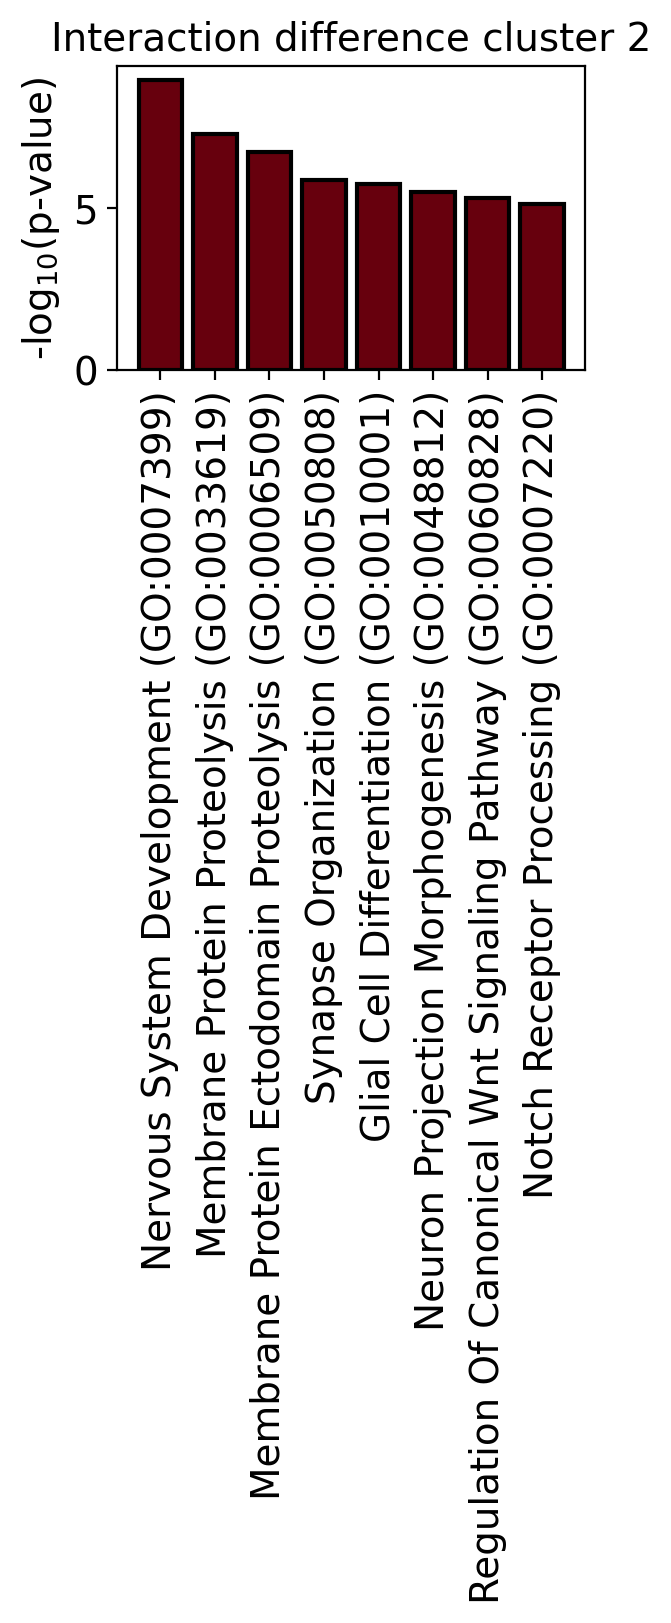

In [75]:
# read in the enrichments (for non-enrichments)
pathways = '''Nervous System Development (GO:0007399)
Membrane Protein Proteolysis (GO:0033619)
Membrane Protein Ectodomain Proteolysis (GO:0006509)
Synapse Organization (GO:0050808)
Glial Cell Differentiation (GO:0010001)
Neuron Projection Morphogenesis (GO:0048812)
Regulation Of Canonical Wnt Signaling Pathway (GO:0060828)
Notch Receptor Processing (GO:0007220)'''.split('\n')
pvals = [float(x) for x in '''1.18E-09
5.32E-08
1.88E-07
1.41E-06
1.88E-06
3.18E-06
5.09E-06
7.61E-06'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 2')

/loc/scratch/7949135/ipykernel_23377/3266868545.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 1')

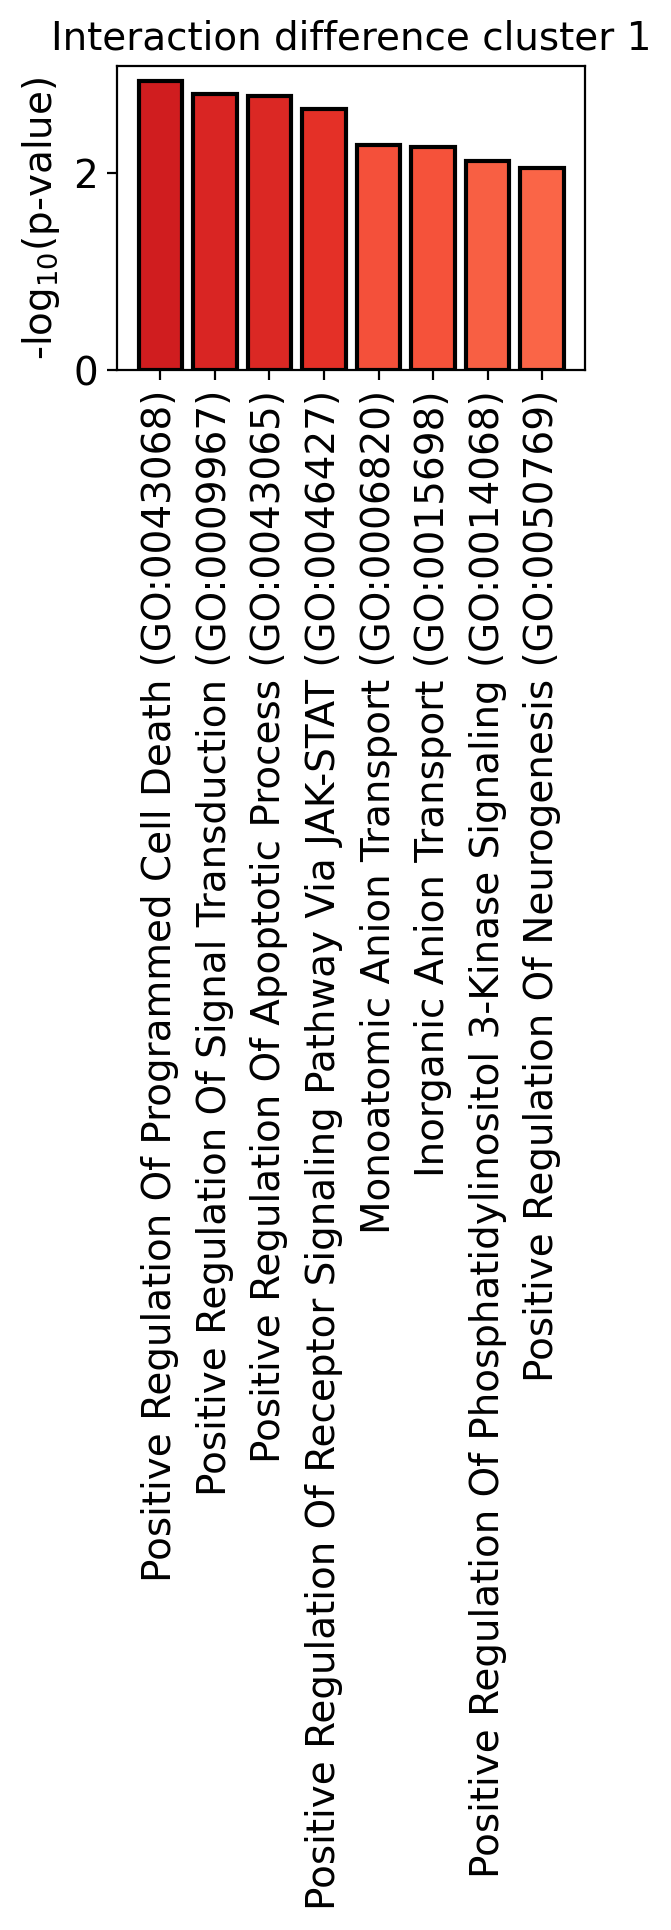

In [76]:
# read in the enrichments (for non-enrichments)
pathways = '''Positive Regulation Of Programmed Cell Death (GO:0043068)
Positive Regulation Of Signal Transduction (GO:0009967)
Positive Regulation Of Apoptotic Process (GO:0043065)
Positive Regulation Of Receptor Signaling Pathway Via JAK-STAT (GO:0046427)
Monoatomic Anion Transport (GO:0006820)
Inorganic Anion Transport (GO:0015698)
Positive Regulation Of Phosphatidylinositol 3-Kinase Signaling (GO:0014068)
Positive Regulation Of Neurogenesis (GO:0050769)'''.split('\n')
pvals = [float(x) for x in '''0.001169353
0.001582337
0.001671171
0.002244891
0.00525265
0.005433758
0.007611311
0.008939035'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 1')